DATA LOAD

In [ ]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # Select your project_spectrogram_data.zip
zip_path = next(iter(uploaded))
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('./project_data')

Saving project_spectrogram_data.zip to project_spectrogram_data (1).zip


In [ ]:
# SET PATHS
CSV_PATH = './project_data/project_spectrogram_data/tracks_metadata.csv'
IMAGE_DIR = './project_data/project_spectrogram_data/spectrogram/'
IMAGE_EXT = '.jpg'
IMAGE_SIZE = (250, 100)
BATCH_SIZE = 32
SEED = 42
MODEL_OUTPUT = 'spectrogram_multilabel.h5'
EPOCHS = 65

In [ ]:
# ---- DataFrame: filter available images + robust tag parsing ----
import pandas as pd
import ast
from pathlib import Path

In [ ]:

df = pd.read_csv(CSV_PATH, usecols=["musicbrainz_recording_id", "final_tags"])
def parse_tags(cell):
    if pd.isna(cell): return []
    try:
        parsed = ast.literal_eval(str(cell))
        if isinstance(parsed, (list, tuple)): return [str(x).strip() for x in parsed]
    except: pass
    s = str(cell).strip().lstrip('[').rstrip(']')
    return [p.strip().strip('"').strip("'") for p in s.split(',') if p.strip()]

In [ ]:
df['parsed_tags'] = df['final_tags'].apply(parse_tags)
df['image_path'] = df['musicbrainz_recording_id'].apply(
    lambda x: os.path.join(IMAGE_DIR, f"{x}{IMAGE_EXT}")
)
df['image_exists'] = df['image_path'].apply(os.path.exists)
df = df[df['image_exists']].reset_index(drop=True)

print(f"Kept {len(df)} samples with images")

Kept 1083 samples with images


In [ ]:
# ---- MultiLabel Binarizer & label array ----
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
mlb.fit(df['parsed_tags'])
classes = list(mlb.classes_)
n_labels = len(classes)
print(f"Found {n_labels} unique tags:", classes)
labels = mlb.transform(df['parsed_tags'])

Found 8 unique tags: ['blues-r&b-soul', 'electronic-funk-disco-dance', 'folk-classical-country-jazz', 'hip_hop-rap', 'opera-musical-theater-soundtrack-vocal-a_cappella', 'others', 'pop', 'rock-metal-psychedelic']


In [ ]:
# ---- Train / Val / Test split ----
from sklearn.model_selection import train_test_split
paths = df['image_path'].tolist()
train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths, labels, test_size=0.15, random_state=SEED
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.15, random_state=SEED
)

In [ ]:
# ---- TensorFlow Dataset ----
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
def load_and_preprocess_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

In [ ]:
def augment_image(img, label):
    img = tf.image.random_brightness(img, max_delta=0.08)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    if tf.random.uniform(()) > 0.7:
        img = tf.roll(img, shift=tf.random.uniform((), -10, 10, dtype=tf.int32), axis=1)
        if tf.random.uniform(()) > 0.7:
            img = tf.roll(img, shift=tf.random.uniform((), -5, 5, dtype=tf.int32), axis=0)
    return img, label

In [ ]:
def make_tf_dataset(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training: ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if training: ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [ ]:
train_ds = make_tf_dataset(train_paths, train_labels, training=True)
val_ds = make_tf_dataset(val_paths, val_labels, training=False)
test_ds = make_tf_dataset(test_paths, test_labels, training=False)

CUSTOM CNN

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import json
import itertools
from sklearn.metrics import confusion_matrix

In [ ]:
# ---- Model Definition ----
def build_model(input_shape=(250, 100, 3), n_labels=n_labels, dropout_rate=0.5):
    inp = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)
    return tf.keras.Model(inp, out)

model = build_model(input_shape=(*IMAGE_SIZE, 3), n_labels=n_labels)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 250, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 125, 50, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 50, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 50, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 31, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 31, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,208 (1.75 MB)

 Trainable params: 457,736 (1.75 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
# ---- Compile & Train ----
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(MODEL_OUTPUT, monitor='val_loss', save_best_only=True)
]
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - auc: 0.4890 - binary_accuracy: 0.5053 - loss: 0.9349

25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 544ms/step - auc: 0.4894 - binary_accuracy: 0.5054 - loss: 0.9340 - val_auc: 0.5104 - val_binary_accuracy: 0.5045 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 2/65
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - auc: 0.5215 - binary_accuracy: 0.5089 - loss: 0.8768

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - auc: 0.5223 - binary_accuracy: 0.5099 - loss: 0.8758 - val_auc: 0.5154 - val_binary_accuracy: 0.5045 - val_loss: 0.6934 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - auc: 0.5450 - binary_accuracy: 0.5327 - loss: 0.8440 - val_auc: 0.5083 - val_binary_accuracy: 0.5145 - val_loss: 0.6968 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - auc: 0.5619 - binary_accuracy: 0.5587 - loss: 0.8200 - val_auc: 0.5079 - val_binary_accuracy: 0.5136 - val_loss: 0.7123 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - auc: 0.5634 - binary_accuracy: 0.5476 - loss: 0.8058 - val_auc: 0.5000 - val_binary_accuracy: 0.5136 - val_loss: 0.7316 - learning_rate: 5.0000e-05
Epoch 6/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - auc: 0.5472 - binary_accuracy: 0.5450 - loss: 0.8208 - val_auc: 0.5075 - val_binary_accuracy: 0.5136 - val_loss: 0.7764 - learning_rate: 5.0000e-05
Epoch

In [ ]:
# ---- Save model in .h5 format ----
model.save('model_final_custom_cnn.h5')

# If in Google Colab environment, add code to download the file
try:
    from google.colab import files
    files.download('model_final_custom_cnn.h5')
except ImportError:
    pass  # Not Colab or no download needed

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ---- Evaluation & Sample Inference ----
print('\nEvaluating on test set...')
results = model.evaluate(test_ds)
print(results)

with open('classes.json', 'w') as f:
    json.dump({'classes': classes}, f)


Evaluating on test set...
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - auc: 0.5011 - binary_accuracy: 0.5287 - loss: 0.6888
[0.6900505423545837, 0.5031279921531677, 0.5245398879051208]


In [ ]:
# ---- Confusion Matrix Visualization ----
# Utility function to plot the confusion matrix
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step


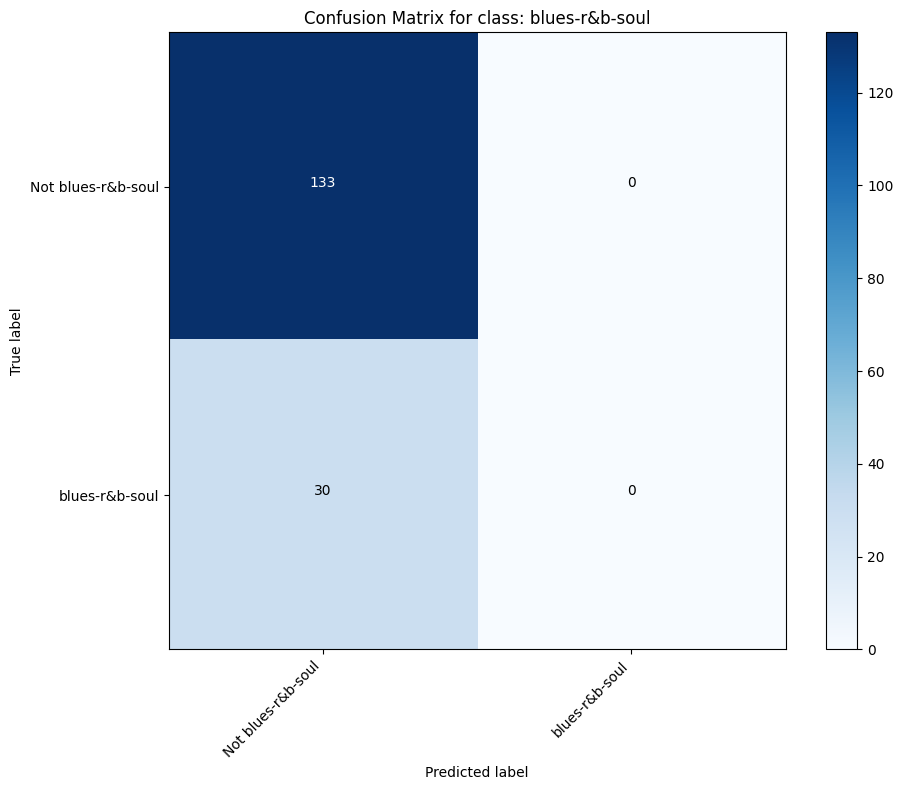

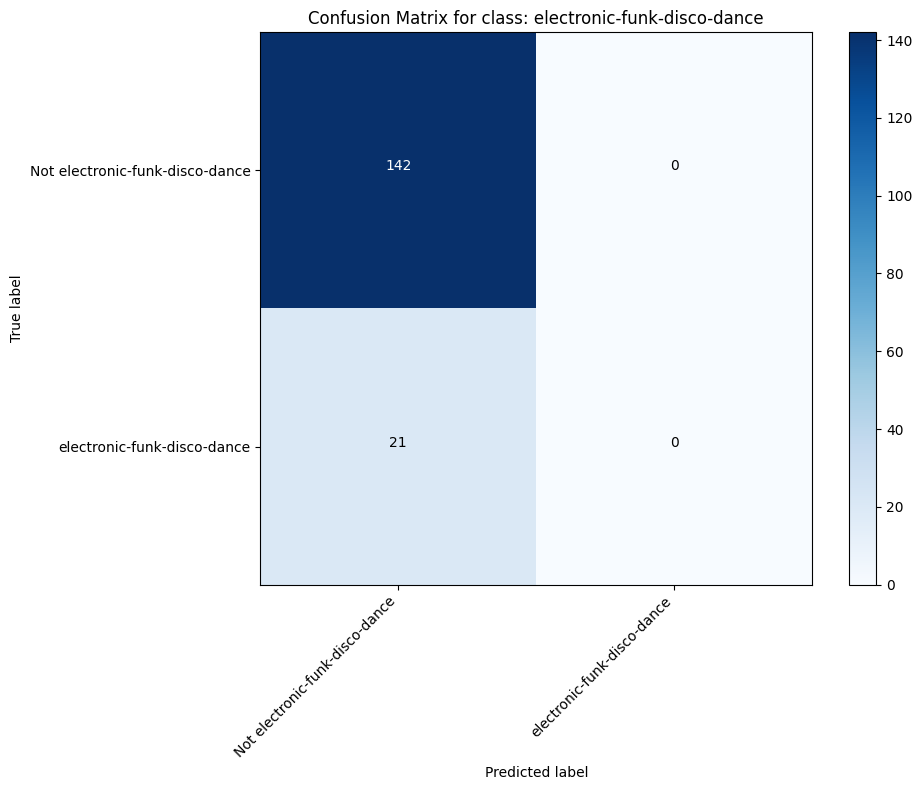

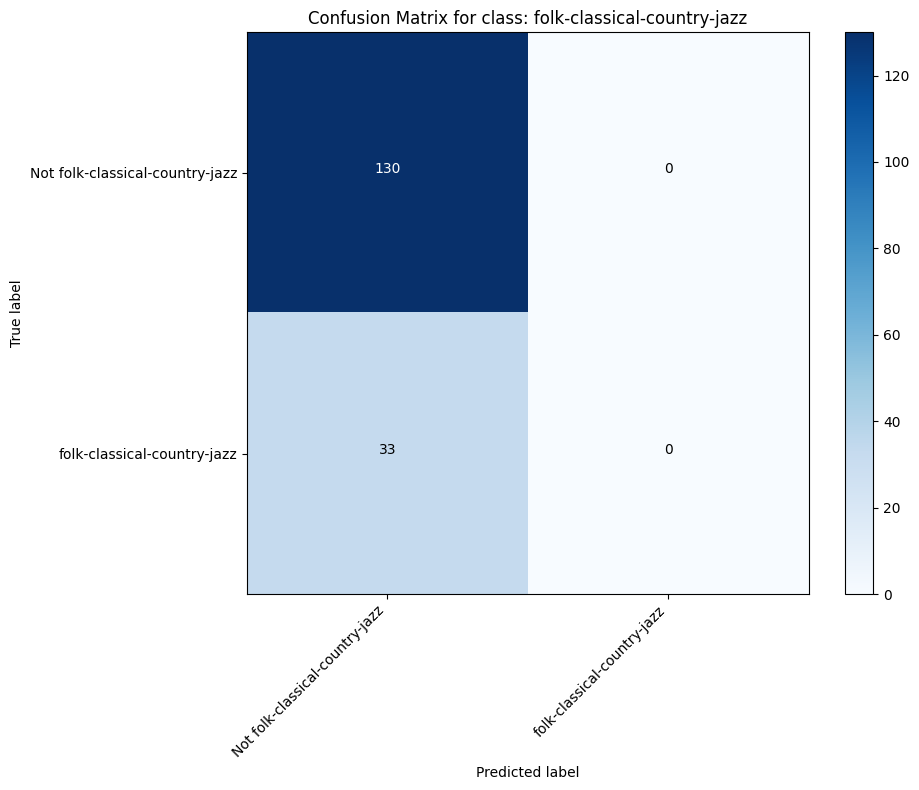

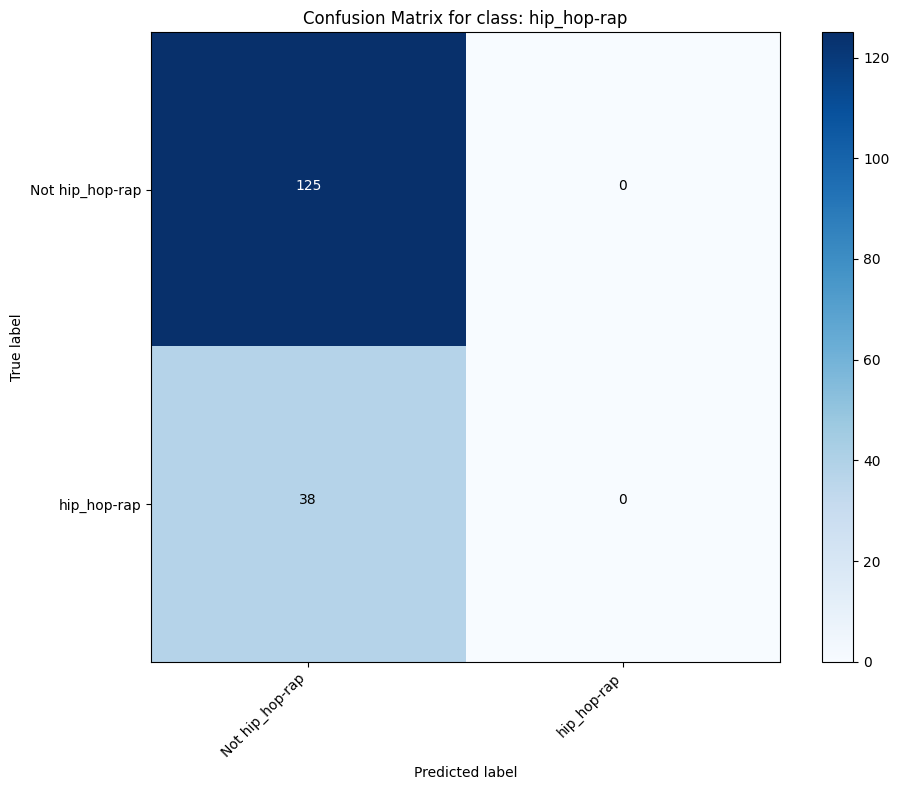

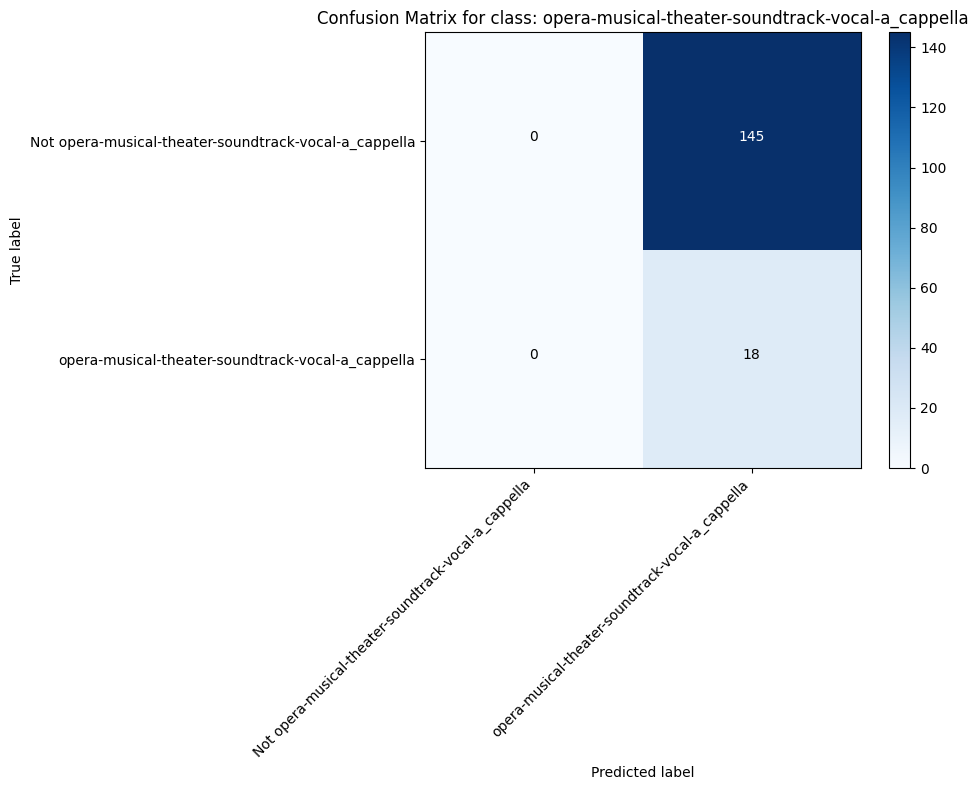

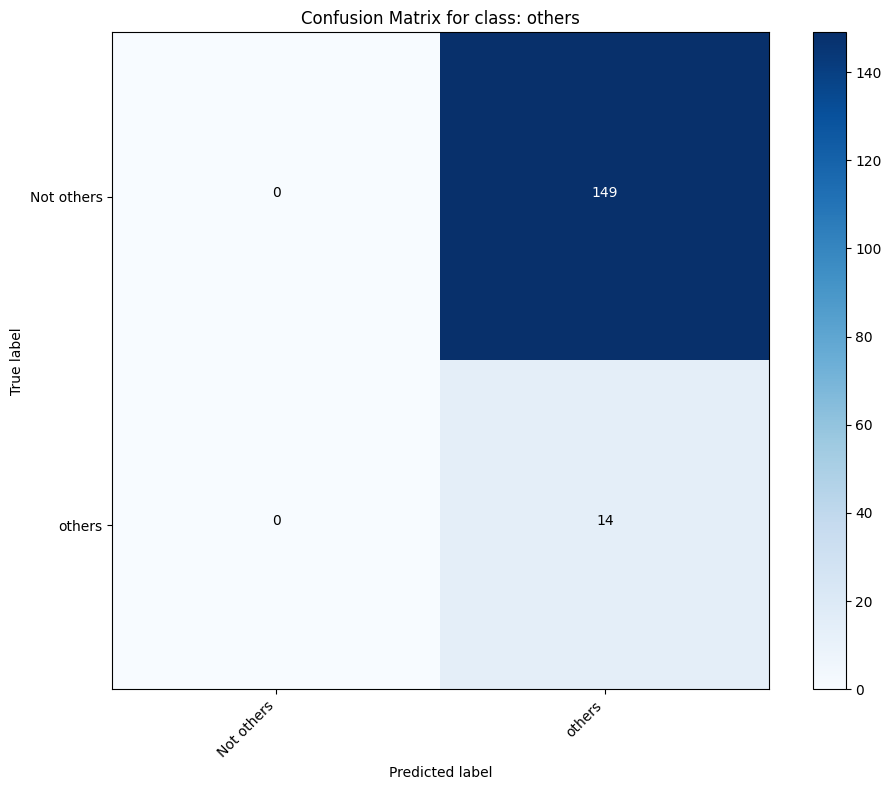

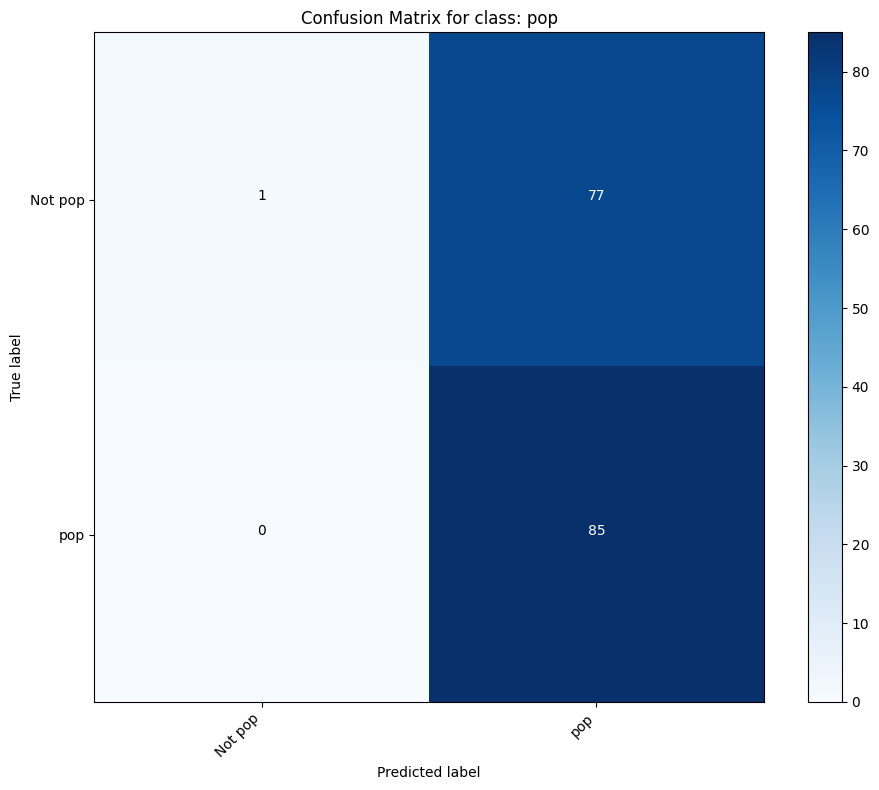

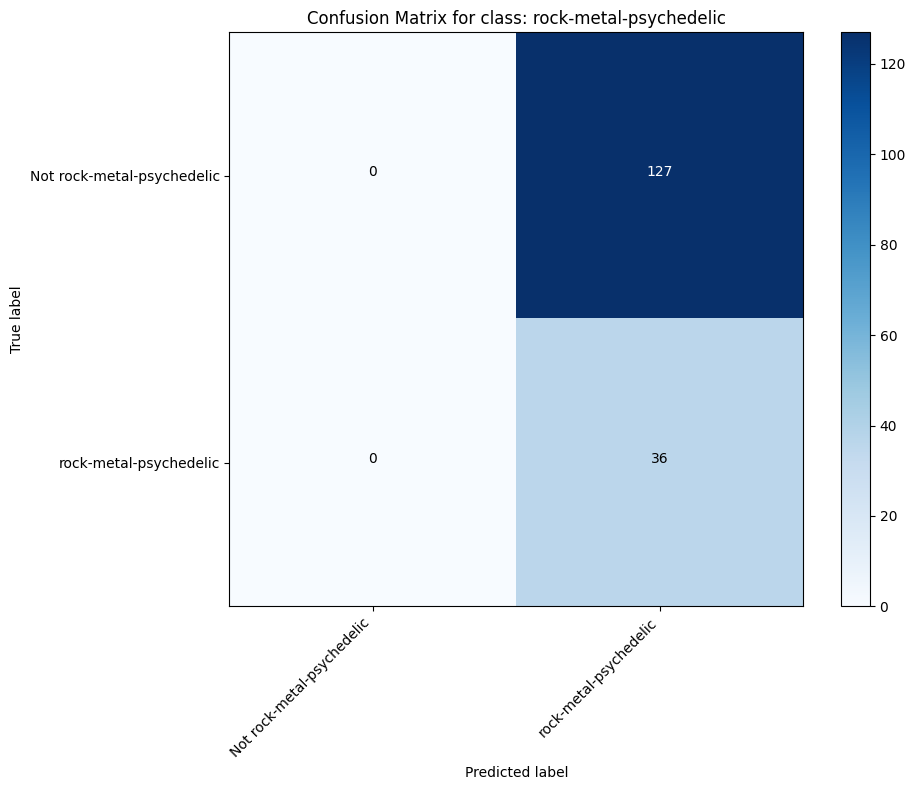

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    # Binarize predictions at 0.5 threshold
    preds_binary = (preds > 0.5).astype(int)
    y_true.append(labels.numpy())
    y_pred.append(preds_binary)

y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)

# For multi-label, one way is to compute confusion matrix per class
for idx, class_name in enumerate(classes):
    cm = confusion_matrix(y_true[:, idx], y_pred[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

HYPERPARAMETER TUNING

In [ ]:
pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.5 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

In [ ]:

def build_model_hp(hp):
    inp = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
    x = tf.keras.layers.Conv2D(
        filters=hp.Int('filters_conv1', 16, 64, step=16),
        kernel_size=3,
        padding='same',
        activation='relu'
    )(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)

    x = tf.keras.layers.Conv2D(
        filters=hp.Int('filters_conv2', 32, 128, step=32),
        kernel_size=3,
        padding='same',
        activation='relu'
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)

    x = tf.keras.layers.Conv2D(
        filters=hp.Int('filters_conv3', 64, 256, step=64),
        kernel_size=3,
        padding='same',
        activation='relu'
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)

    x = tf.keras.layers.Conv2D(
        filters=hp.Int('filters_conv4', 128, 512, step=128),
        kernel_size=3,
        padding='same',
        activation='relu'
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dropout(rate=hp.Float('dropout_rate', 0.2, 0.7, step=0.1))(x)
    x = tf.keras.layers.Dense(
        units=hp.Int('units_dense', 128, 512, step=64),
        activation='relu'
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(rate=hp.Float('dropout_rate_2', 0.2, 0.7, step=0.1))(x)

    out = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)
    model = tf.keras.Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
    )

    return model

tuner = kt.RandomSearch(
    build_model_hp,
    objective='val_binary_accuracy',
    max_trials=10,
    executions_per_trial=2,
    directory='kt_tuner_dir',
    project_name='music_tag_multilabel'
)

tuner.search_space_summary()

tuner.search(train_ds, validation_data=val_ds, epochs=15, batch_size=BATCH_SIZE)

# Best model summary and hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model.summary()
print("Best hyperparameters:", best_hp.values)

Trial 10 Complete [00h 02m 02s]
val_binary_accuracy: 0.6136775314807892

Best val_binary_accuracy So Far: 0.8048007190227509
Total elapsed time: 00h 19m 03s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 250, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 125, 50, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 50, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 50, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 31, 12, 384)    │       221,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 31, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 384)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 320)            │       123,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 320)            │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,112 (1.55 MB)

 Trainable params: 405,384 (1.55 MB)

 Non-trainable params: 1,728 (6.75 KB)

Best hyperparameters: {'filters_conv1': 32, 'filters_conv2': 64, 'filters_conv3': 64, 'filters_conv4': 384, 'dropout_rate': 0.4, 'units_dense': 320, 'dropout_rate_2': 0.4, 'learning_rate': 0.01}


In [ ]:
tuner.results_summary()

Results summary
Results in kt_tuner_dir/music_tag_multilabel
Showing 10 best trials
Objective(name="val_binary_accuracy", direction="max")

Trial 03 summary
Hyperparameters:
filters_conv1: 32
filters_conv2: 64
filters_conv3: 64
filters_conv4: 384
dropout_rate: 0.4
units_dense: 320
dropout_rate_2: 0.4
learning_rate: 0.01
Score: 0.8048007190227509

Trial 01 summary
Hyperparameters:
filters_conv1: 16
filters_conv2: 128
filters_conv3: 64
filters_conv4: 128
dropout_rate: 0.2
units_dense: 512
dropout_rate_2: 0.30000000000000004
learning_rate: 0.01
Score: 0.7984601557254791

Trial 04 summary
Hyperparameters:
filters_conv1: 16
filters_conv2: 96
filters_conv3: 192
filters_conv4: 384
dropout_rate: 0.4
units_dense: 448
dropout_rate_2: 0.6000000000000001
learning_rate: 0.01
Score: 0.7980072498321533

Trial 00 summary
Hyperparameters:
filters_conv1: 16
filters_conv2: 96
filters_conv3: 192
filters_conv4: 384
dropout_rate: 0.30000000000000004
units_dense: 192
dropout_rate_2: 0.5
learning_rate: 0.01
S

In [ ]:
for trial in tuner.oracle.get_best_trials(num_trials=len(tuner.oracle.trials)):
    print(f"Trial ID: {trial.trial_id}")
    print("Hyperparameters:")
    print(trial.hyperparameters.values)
    print(f"Score: {trial.score}\n")

Trial ID: 03
Hyperparameters:
{'filters_conv1': 32, 'filters_conv2': 64, 'filters_conv3': 64, 'filters_conv4': 384, 'dropout_rate': 0.4, 'units_dense': 320, 'dropout_rate_2': 0.4, 'learning_rate': 0.01}
Score: 0.8048007190227509

Trial ID: 01
Hyperparameters:
{'filters_conv1': 16, 'filters_conv2': 128, 'filters_conv3': 64, 'filters_conv4': 128, 'dropout_rate': 0.2, 'units_dense': 512, 'dropout_rate_2': 0.30000000000000004, 'learning_rate': 0.01}
Score: 0.7984601557254791

Trial ID: 04
Hyperparameters:
{'filters_conv1': 16, 'filters_conv2': 96, 'filters_conv3': 192, 'filters_conv4': 384, 'dropout_rate': 0.4, 'units_dense': 448, 'dropout_rate_2': 0.6000000000000001, 'learning_rate': 0.01}
Score: 0.7980072498321533

Trial ID: 00
Hyperparameters:
{'filters_conv1': 16, 'filters_conv2': 96, 'filters_conv3': 192, 'filters_conv4': 384, 'dropout_rate': 0.30000000000000004, 'units_dense': 192, 'dropout_rate_2': 0.5, 'learning_rate': 0.01}
Score: 0.7961956560611725

Trial ID: 07
Hyperparameters:


In [ ]:
# Get the best trial ID
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial_id = best_trial.trial_id
best_trial_score = best_trial.score  # best validation binary accuracy

# Get the best hyperparameters and model
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

print(f"Best Trial Number: {best_trial_id}")
print(f"Best Validation Binary Accuracy: {best_trial_score:.4f}")
print("Best Trial Hyperparameters:")
print(best_hp.values)

print("\nBest Model Summary:")
best_model.summary()

Best Trial Number: 03
Best Validation Binary Accuracy: 0.8048
Best Trial Hyperparameters:
{'filters_conv1': 32, 'filters_conv2': 64, 'filters_conv3': 64, 'filters_conv4': 384, 'dropout_rate': 0.4, 'units_dense': 320, 'dropout_rate_2': 0.4, 'learning_rate': 0.01}

Best Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 250, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 250, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 125, 50, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 50, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 50, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 62, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 31, 12, 384)    │       221,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 31, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 384)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 320)            │       123,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 320)            │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,112 (1.55 MB)

 Trainable params: 405,384 (1.55 MB)

 Non-trainable params: 1,728 (6.75 KB)

LENET-5

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
# ---- Model Definition ----
def build_lenet5(input_shape=(250, 100, 3), n_labels=n_labels):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(6, kernel_size=5, padding='same', activation='tanh')(inputs)
    x = tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(x)

    x = tf.keras.layers.Conv2D(16, kernel_size=5, activation='tanh')(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(120, activation='tanh')(x)
    x = tf.keras.layers.Dense(84, activation='tanh')(x)

    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build model
lenet_model = build_lenet5()
lenet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 250, 100, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 125, 50, 6)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 121, 46, 16)    │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 60, 23, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 22080)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │     2,649,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           680 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,663,436 (10.16 MB)

 Trainable params: 2,663,436 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile
lenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

In [ ]:
# Callbacks for training
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
]

In [ ]:
# Train
history = lenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 487ms/step - auc_1: 0.5097 - binary_accuracy: 0.7395 - loss: 0.5311 - val_auc_1: 0.6534 - val_binary_accuracy: 0.7935 - val_loss: 0.4711 - learning_rate: 0.0010
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - auc_1: 0.6462 - binary_accuracy: 0.7986 - loss: 0.4591 - val_auc_1: 0.7417 - val_binary_accuracy: 0.8125 - val_loss: 0.4279 - learning_rate: 0.0010
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - auc_1: 0.6969 - binary_accuracy: 0.8051 - loss: 0.4492 - val_auc_1: 0.7152 - val_binary_accuracy: 0.8107 - val_loss: 0.4395 - learning_rate: 0.0010
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - auc_1: 0.7529 - binary_accuracy: 0.8169 - loss: 0.4196 - val_auc_1: 0.7369 - val_binary_accuracy: 0.8134 - val_loss: 0.4256 - learning_rate: 0.0010
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - auc_1: 0.7629 - binary_accuracy: 0.8247 - loss: 0.4134 - val_auc_1: 0.7456 - val_binary_accuracy: 0.8134 - val_loss: 0.4180 - learning_rate

In [ ]:
# Save model as .h5
lenet_model.save('lenet_model_final.h5')

# Download model file if in Google Colab
try:
    from google.colab import files
    files.download('lenet_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate on test set
print("\nEvaluation on test set:")
results = lenet_model.evaluate(test_ds)
print(results)


Evaluation on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - auc_1: 0.8002 - binary_accuracy: 0.8417 - loss: 0.3720
[0.3747048079967499, 0.7968038320541382, 0.842024564743042]


In [ ]:
# ---- Confusion Matrix Visualization ----
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Gather true and predicted labels from test_ds
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = lenet_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step


In [ ]:
# Binarize predictions (threshold 0.5)
pred_labels = (pred_probs > 0.5).astype(int)

# Binary accuracy overall
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.8420


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.60      0.40      0.48        30
                      electronic-funk-disco-dance       0.50      0.29      0.36        21
                      folk-classical-country-jazz       0.61      0.33      0.43        33
                                      hip_hop-rap       0.85      0.58      0.69        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.27      0.17      0.21        18
                                           others       0.43      0.21      0.29        14
                                              pop       0.75      0.75      0.75        85
                           rock-metal-psychedelic       0.58      0.61      0.59        36

                                        micro avg       0.66      0.52      0.58       275
                                        macro avg    

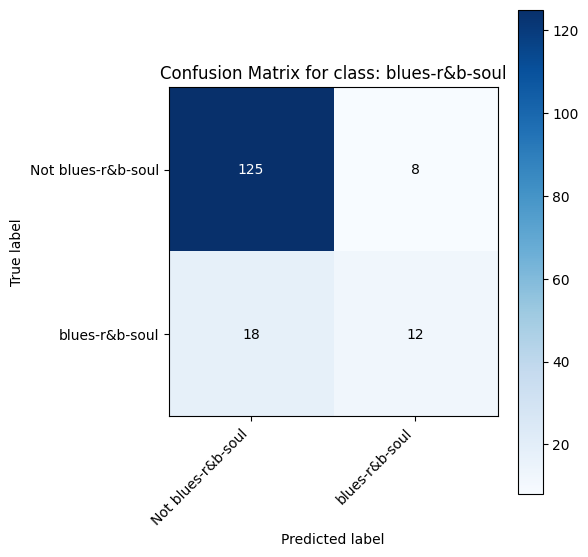

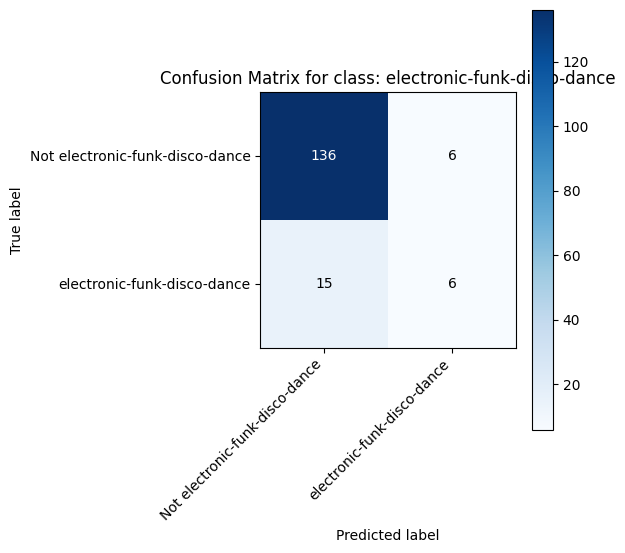

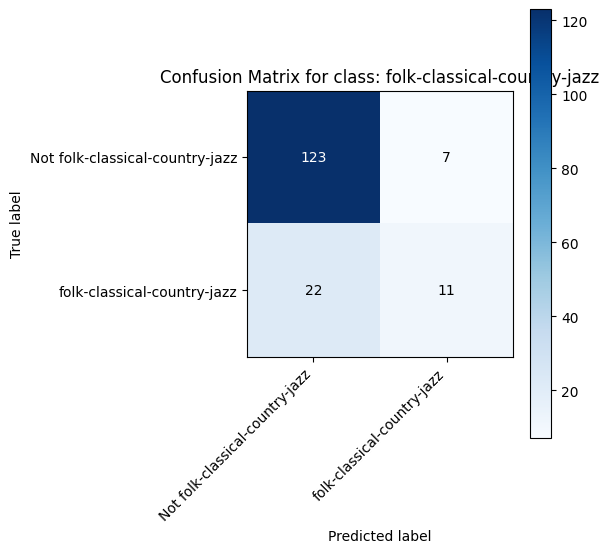

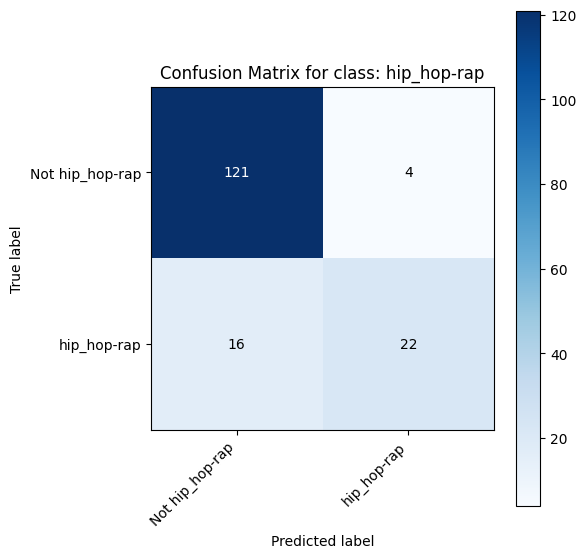

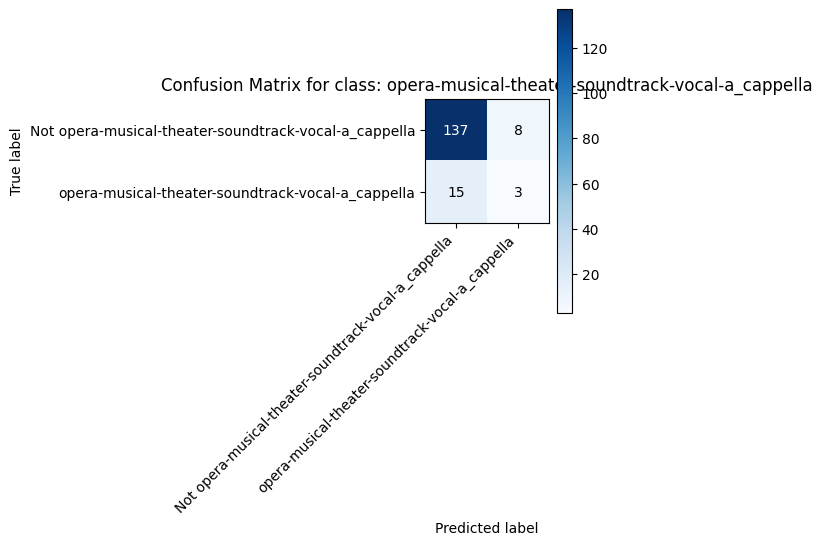

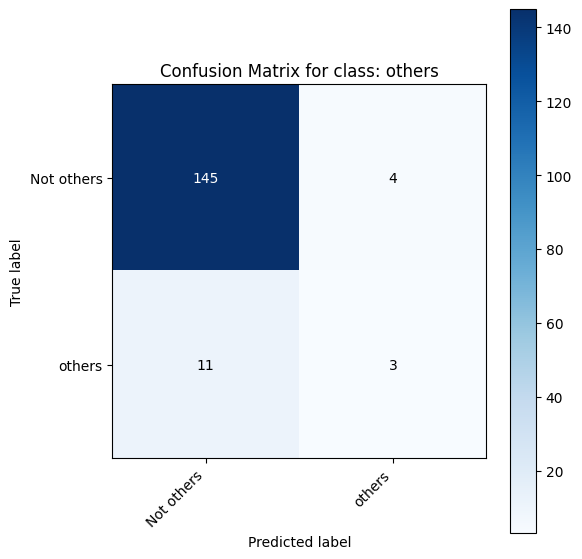

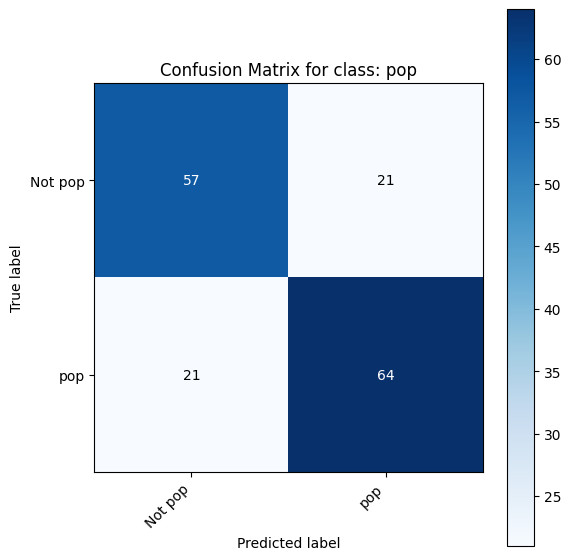

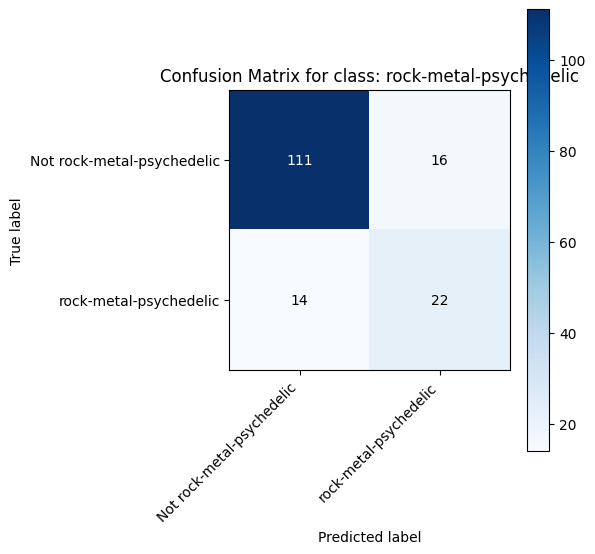

In [ ]:
# Classification report with zero_division=0 to avoid warnings for no predicted samples
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Confusion matrix per class
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

### Model Evaluation Summary

The convolutional neural network achieved a **binary accuracy of 84.2%** and an **AUC of approximately 0.80** on the test dataset, indicating a strong ability to distinguish between the music genres. The **loss value of 0.37** suggests the model generalizes reasonably well without major overfitting.

From the classification report:

- The model performs best on **Pop** and **Hip Hop/Rap** categories, with relatively high recall and F1-scores, likely due to a larger number of training instances or more distinct audio features.
- **Blues-R&B-Soul** and **Rock-Metal-Psychedelic** show moderate performance, indicating partial feature overlap with other genres.
- **Opera-Musical-Theater-Soundtrack-Vocal** and **Others** have lower metrics, which could be due to underrepresentation or high intra-class variability.
- The **macro average F1-score (0.48)** and **weighted average F1-score (0.57)** suggest that while the model captures dominant genres effectively, performance across all classes remains somewhat imbalanced.

Overall, the model demonstrates good generalization for major genres but may require dataset balancing, additional augmentation, or fine-tuning to improve recognition of underrepresented categories.

ALEXNET

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_alexnet(input_shape=(250, 100, 3), n_labels=n_labels):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(96, kernel_size=11, strides=4, activation='relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=3, strides=2)(x)

    x = tf.keras.layers.Conv2D(256, kernel_size=5, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=3, strides=2)(x)

    x = tf.keras.layers.Conv2D(384, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv2D(384, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(pool_size=3, strides=2)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
alexnet_model = build_alexnet()
alexnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

alexnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 23, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 23, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 29, 11, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 11, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 29, 11, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 5, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 5, 384)     │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 5, 384)     │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 5, 384)     │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 5, 384)     │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 5, 256)     │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 5, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4096)           │    12,587,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │        32,776 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,153,800 (126.47 MB)

 Trainable params: 33,151,048 (126.46 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [ ]:
# Callbacks for training
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

In [ ]:
# Train
history = alexnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 514ms/step - auc_2: 0.5185 - binary_accuracy: 0.7029 - loss: 0.8837 - val_auc_2: 0.5541 - val_binary_accuracy: 0.6476 - val_loss: 0.6497 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - auc_2: 0.5900 - binary_accuracy: 0.7579 - loss: 0.5754 - val_auc_2: 0.5479 - val_binary_accuracy: 0.7889 - val_loss: 0.5907 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - auc_2: 0.6151 - binary_accuracy: 0.7705 - loss: 0.5373 - val_auc_2: 0.5234 - val_binary_accuracy: 0.7889 - val_loss: 0.5497 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - auc_2: 0.6068 - binary_accuracy: 0.7869 - loss: 0.5163 - val_auc_2: 0.5574 - val_binary_accuracy: 0.7889 - val_loss: 0.5174 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - auc_2: 0.6443 - binary_accuracy: 0.7900 - loss: 0.4886 - val_auc_2: 0.6044 - val_binary_accuracy: 0.7889 - val_loss: 0.5236

In [ ]:
# Save the trained model
alexnet_model.save('alexnet_model_final.h5')

# Download the model if in Google Colab
try:
    from google.colab import files
    files.download('alexnet_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate on test set
print("\nEvaluating on test set:")
test_results = alexnet_model.evaluate(test_ds)
print(test_results)


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 318ms/step - auc_2: 0.5374 - binary_accuracy: 0.7871 - loss: 0.5195
[0.5181604623794556, 0.5427928566932678, 0.7891104221343994]


In [ ]:
# Confusion matrix plotting util
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Gather true labels and predictions for the test dataset
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = alexnet_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.7891


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.00      0.00      0.00        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.00      0.00      0.00        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.00      0.00      0.00        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.00      0.00      0.00        85
                           rock-metal-psychedelic       0.00      0.00      0.00        36

                                        micro avg       0.00      0.00      0.00       275
                                        macro avg    

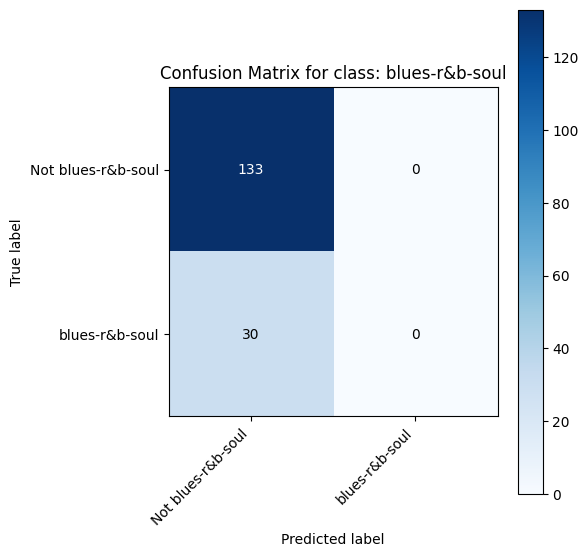

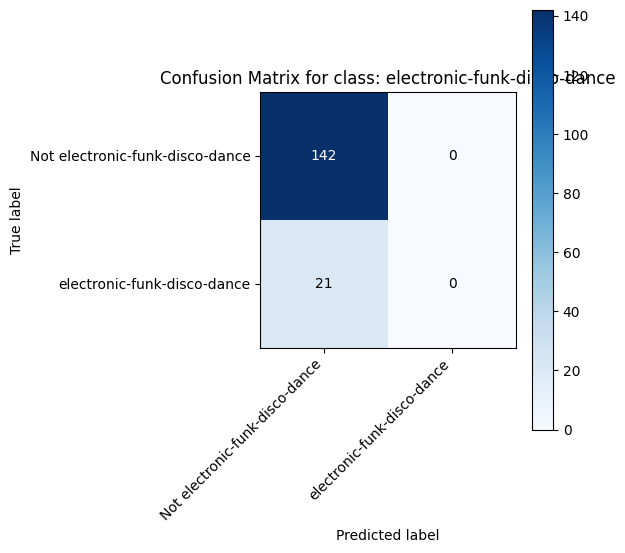

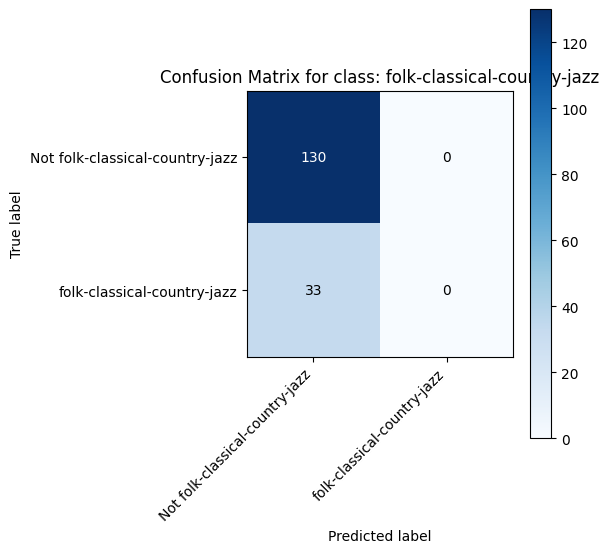

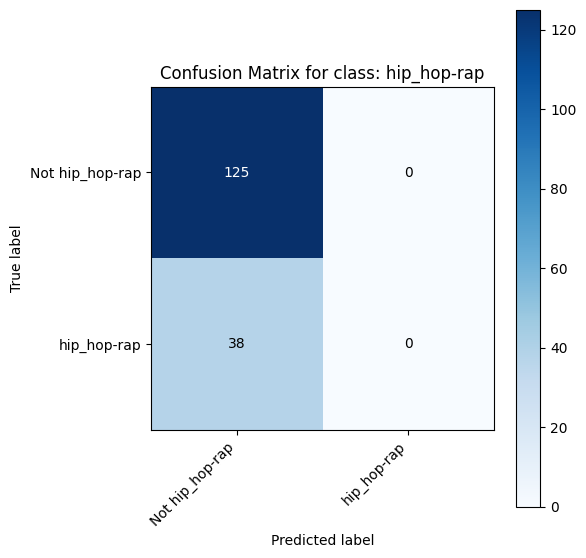

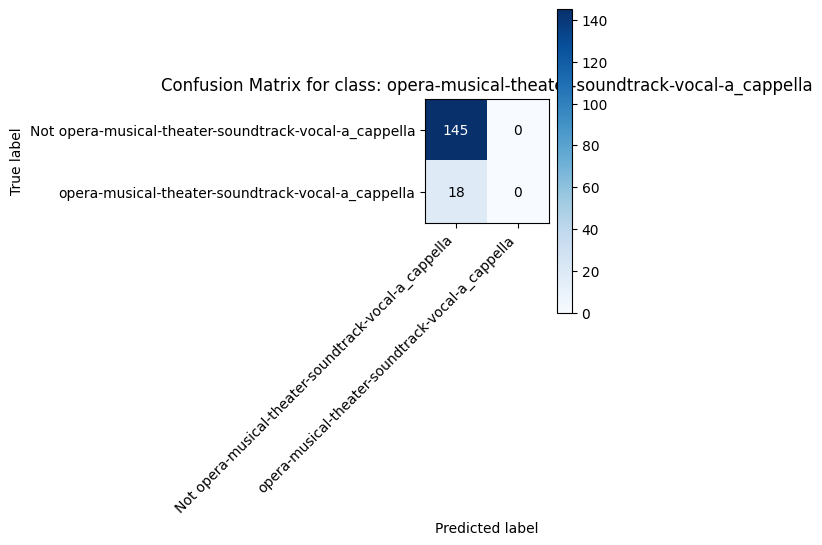

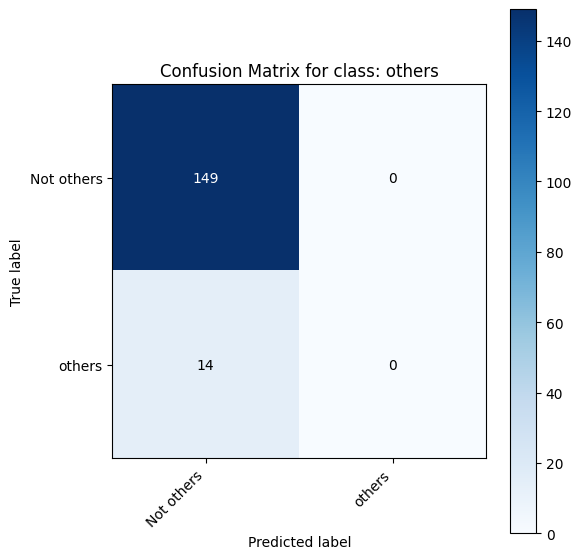

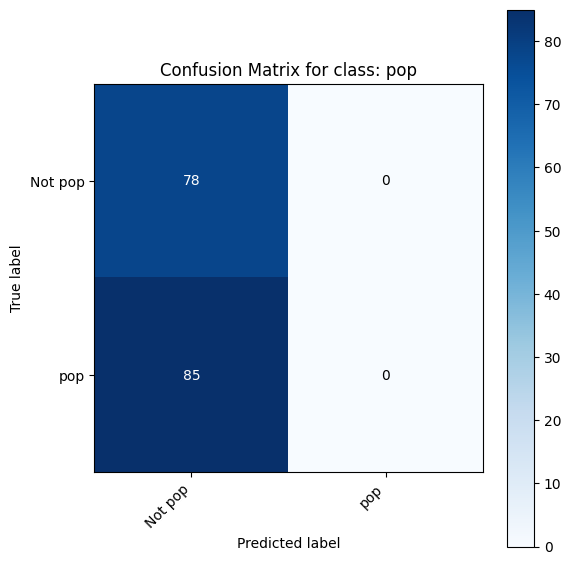

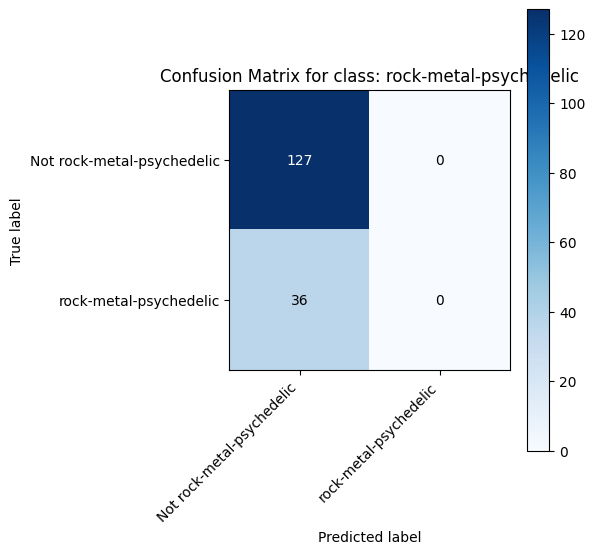

In [ ]:
# Classification report per label
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Plot confusion matrix per class for multi-label task
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

VGG11

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_vgg11(input_shape=(250, 100, 3), n_labels=n_labels):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
vgg11_model = build_vgg11()
vgg11_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

vgg11_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 250, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 125, 50, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 125, 50, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 62, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 62, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 31, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 31, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 6, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4096)           │    44,044,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │        32,776 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,078,856 (267.33 MB)

 Trainable params: 70,078,856 (267.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

In [ ]:
# Train
history = vgg11_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - auc_3: 0.5093 - binary_accuracy: 0.7455 - loss: 0.5764 - val_auc_3: 0.5461 - val_binary_accuracy: 0.7799 - val_loss: 0.4913 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - auc_3: 0.4952 - binary_accuracy: 0.7815 - loss: 0.4924 - val_auc_3: 0.5499 - val_binary_accuracy: 0.7799 - val_loss: 0.4854 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 181ms/step - auc_3: 0.5204 - binary_accuracy: 0.7891 - loss: 0.4852 - val_auc_3: 0.5476 - val_binary_accuracy: 0.7889 - val_loss: 0.4866 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - auc_3: 0.4905 - binary_accuracy: 0.7805 - loss: 0.4922 - val_auc_3: 0.5522 - val_binary_accuracy: 0.7889 - val_loss: 0.4860 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - auc_3: 0.5059 - binary_accuracy: 0.7816 - loss: 0.4891 - val_auc_3: 0.5591 - val_binary_accuracy: 0.7799 - val_loss: 0.4949 

In [ ]:
# Save model and download if in Colab
vgg11_model.save('vgg11_model_final.h5')
try:
    from google.colab import files
    files.download('vgg11_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate
print("\nEvaluating on test set:")
test_results = vgg11_model.evaluate(test_ds)
print(test_results)


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 595ms/step - auc_3: 0.7846 - binary_accuracy: 0.8530 - loss: 0.3753
[0.36937621235847473, 0.7950295209884644, 0.849693238735199]


In [ ]:
# Confusion Matrix visualization
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Generate predictions
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = vgg11_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step


In [ ]:
# Overall accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.8497


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.73      0.37      0.49        30
                      electronic-funk-disco-dance       0.80      0.19      0.31        21
                      folk-classical-country-jazz       0.45      0.15      0.23        33
                                      hip_hop-rap       0.76      0.58      0.66        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.25      0.11      0.15        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.75      0.82      0.79        85
                           rock-metal-psychedelic       0.68      0.64      0.66        36

                                        micro avg       0.70      0.50      0.58       275
                                        macro avg    

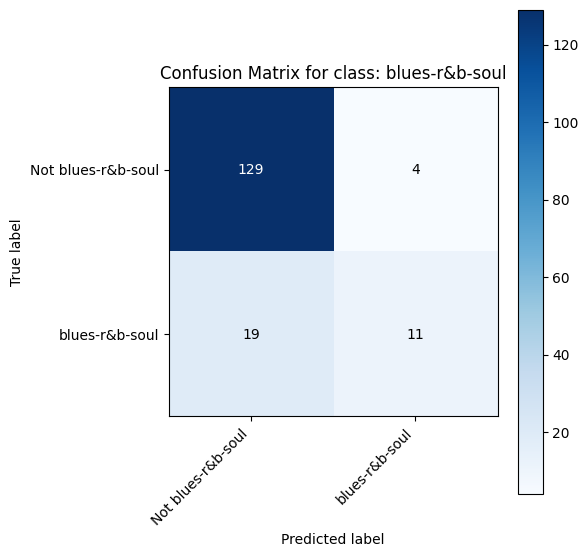

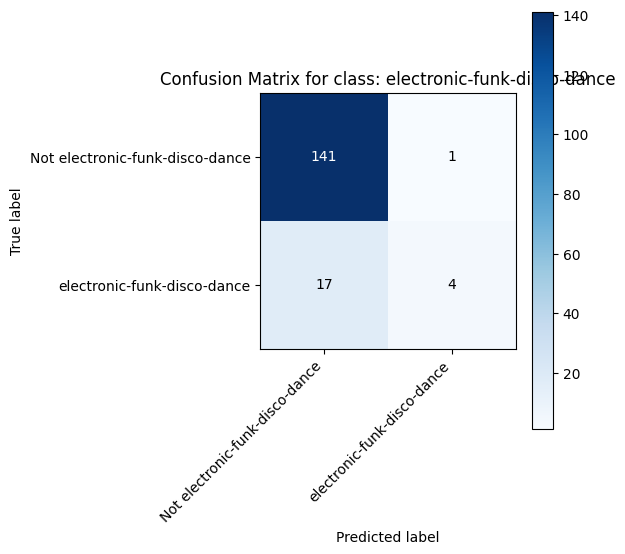

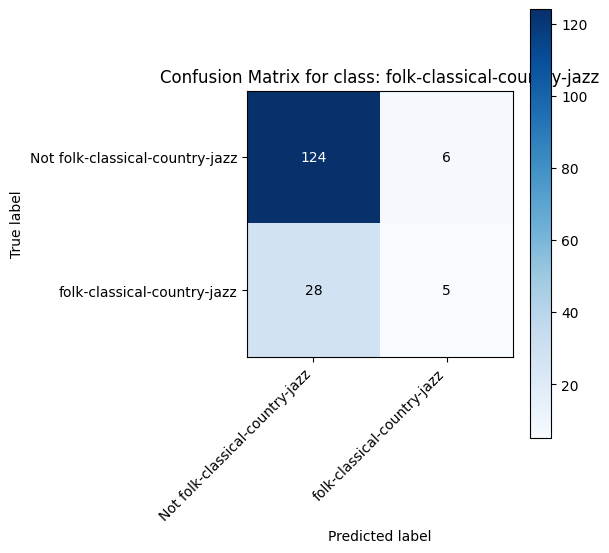

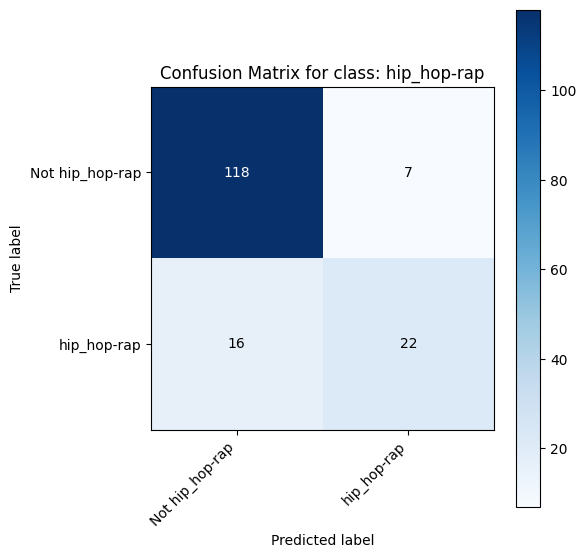

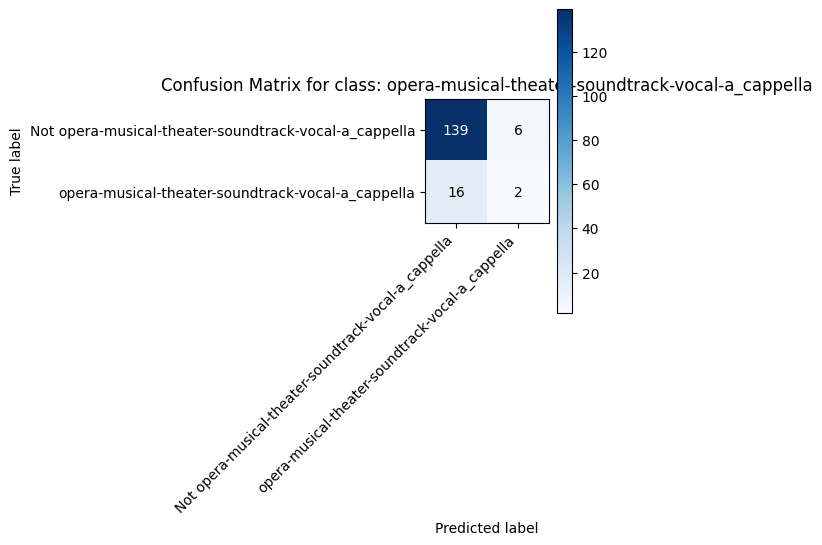

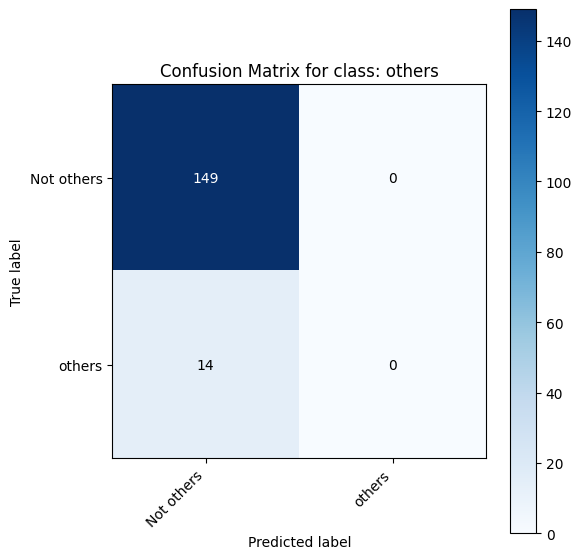

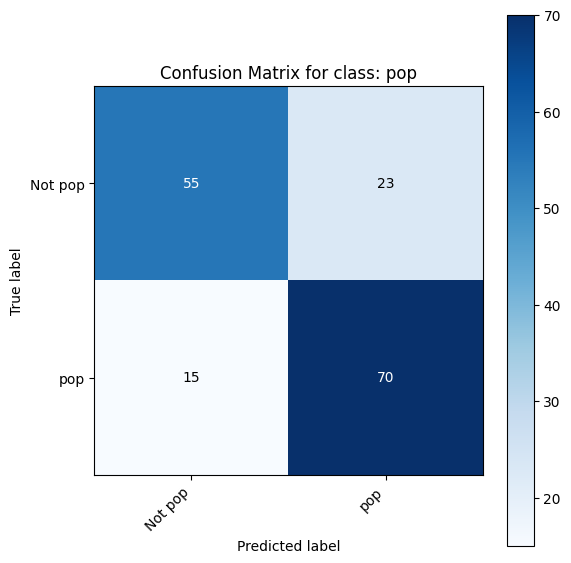

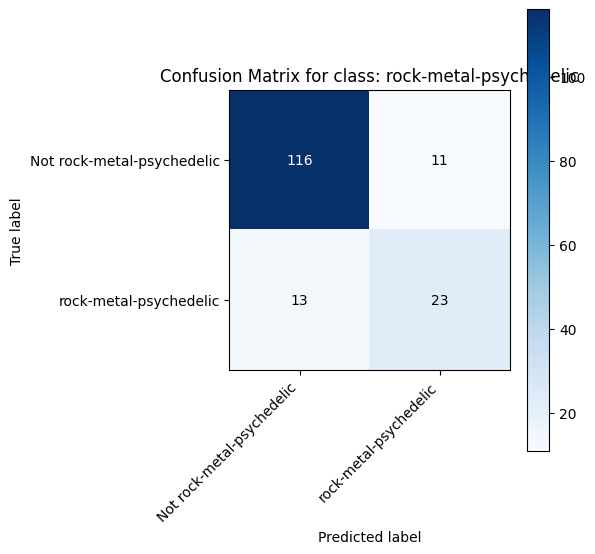

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Plot confusion matrix per class
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

### Model Evaluation Summary

The CNN model yielded a **binary accuracy of 0.8497** with an **AUC score of 0.78** on the test set, suggesting effective separation of musical genres with slightly improved accuracy over previous runs. The **loss of 0.37** is consistent, indicating stable model performance with moderate generalization ability.

#### Class-wise Performance Insights
- **Pop** genre continues to lead in both recall (0.82) and F1-score (0.79), highlighting the model’s high reliability in identifying mainstream music which likely dominates the dataset.
- **Hip Hop/Rap** and **Rock/Metal/Psychedelic** genres also display robust performance, with F1-scores of 0.66, reflecting successful feature extraction from rhythmic and spectral patterns.
- **Blues/R&B/Soul** demonstrates high precision (0.73) but much lower recall (0.37), indicating conservative predictions for this class.
- **Electronic/Funk/Disco/Dance**, **Folk/Classical/Jazz**, and **Opera/Musical/Vocal** classes show low recall and F1 (<0.35), revealing the model’s difficulty in recognizing these less-represented or more heterogeneous genres.
- **Others** class failed to yield correct predictions (F1=0), exemplifying a possible **severe class imbalance** or feature ambiguity for minority categories.

#### Overall Trends
- **Macro F1-score of 0.41** suggests moderate average class-wise performance, with emphasis on underfitting in minority classes.
- **Weighted F1-score of 0.53** is driven mainly by accurate predictions in larger classes.
- Results recommend further dataset balancing, targeted augmentation, and potential architecture adjustments to boost performance on underrepresented genres and mitigate model bias.

The model demonstrates substantial accuracy for major genres but requires focused enhancement for precision and recall in niche categories.

VGG13

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_vgg13(input_shape=(250, 100, 3), n_labels=n_labels):
    inputs = tf.keras.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 4
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 5
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
vgg13_model = build_vgg13()
vgg13_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

vgg13_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 250, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 250, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 125, 50, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 125, 50, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 125, 50, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 62, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 62, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 62, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 31, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 31, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 31, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 15, 6, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4096)           │    44,044,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │        32,776 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,263,368 (268.03 MB)

 Trainable params: 70,263,368 (268.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

In [ ]:
# Train
history = vgg13_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 933ms/step - auc_4: 0.5021 - binary_accuracy: 0.7373 - loss: 0.5932 - val_auc_4: 0.5341 - val_binary_accuracy: 0.7889 - val_loss: 0.4875 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 265ms/step - auc_4: 0.5046 - binary_accuracy: 0.7834 - loss: 0.4904 - val_auc_4: 0.5394 - val_binary_accuracy: 0.7944 - val_loss: 0.4884 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - auc_4: 0.5083 - binary_accuracy: 0.7877 - loss: 0.4834 - val_auc_4: 0.5446 - val_binary_accuracy: 0.7799 - val_loss: 0.4874 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - auc_4: 0.4880 - binary_accuracy: 0.7870 - loss: 0.4910 - val_auc_4: 0.5467 - val_binary_accuracy: 0.7889 - val_loss: 0.4879 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - auc_4: 0.4937 - binary_accuracy: 0.7852 - loss: 0.4954 - val_auc_4: 0.5467 - val_binary_accuracy: 0.7799 - val_loss: 0.49

In [ ]:
# Save model and download if in Colab
vgg13_model.save('vgg13_model_final.h5')
try:
    from google.colab import files
    files.download('vgg13_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate
print("\nEvaluating on test set:")
test_results = vgg13_model.evaluate(test_ds)
print(test_results)


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - auc_4: 0.7984 - binary_accuracy: 0.8410 - loss: 0.3719
[0.3755796253681183, 0.79768306016922, 0.8397239446640015]


In [ ]:
# Confusion matrix plotting utility function
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Generate predictions and labels from test dataset
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = vgg13_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 562ms/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.8397


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.60      0.10      0.17        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.40      0.06      0.11        33
                                      hip_hop-rap       0.75      0.63      0.69        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.33      0.06      0.10        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.75      0.76      0.76        85
                           rock-metal-psychedelic       0.70      0.39      0.50        36

                                        micro avg       0.72      0.40      0.51       275
                                        macro avg    

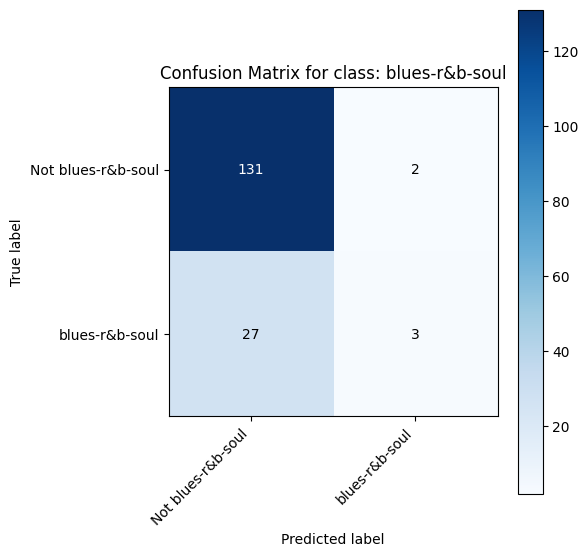

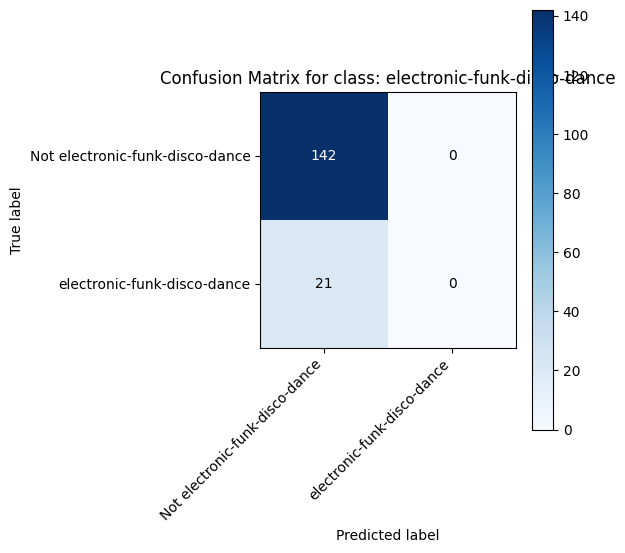

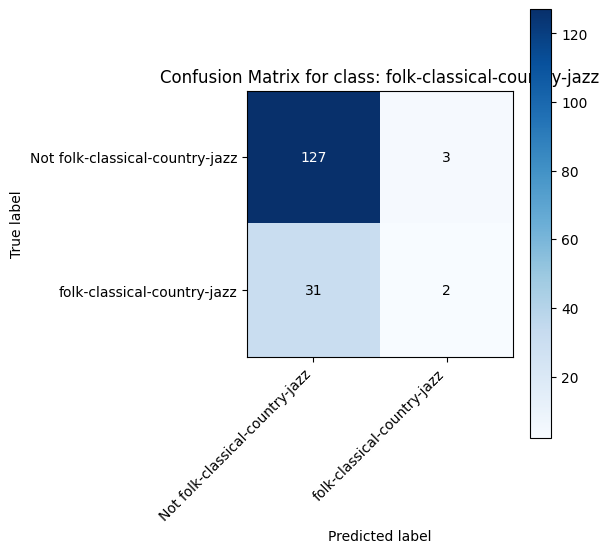

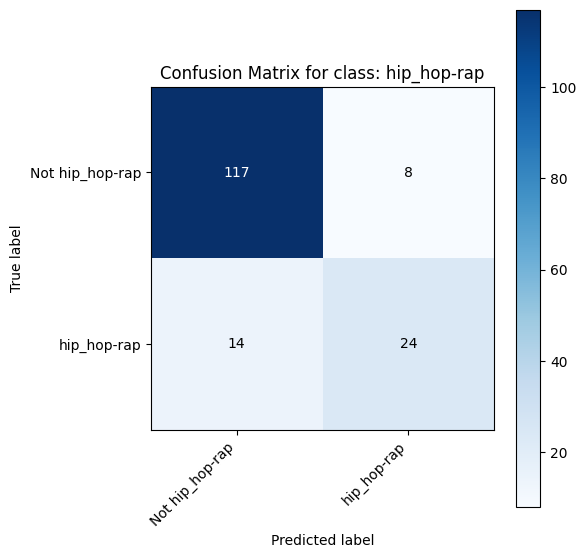

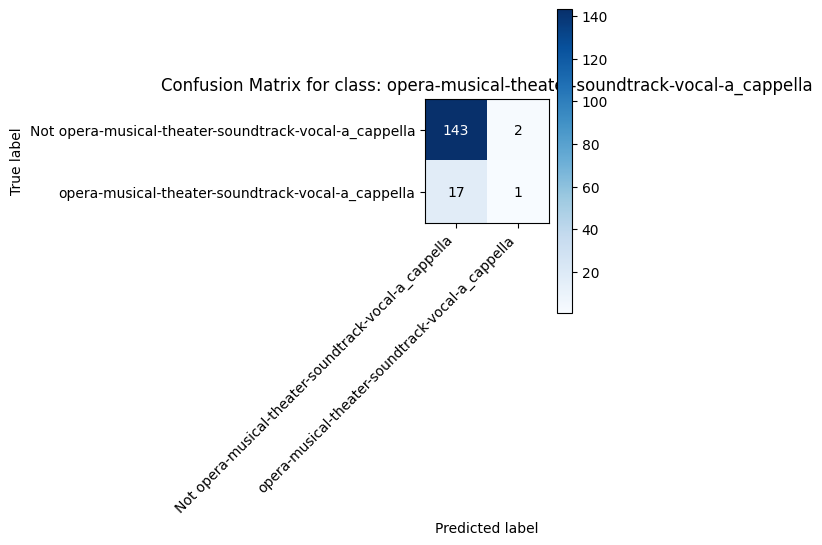

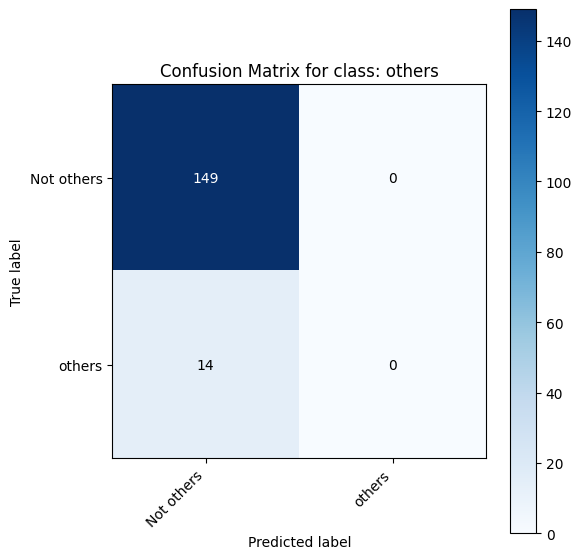

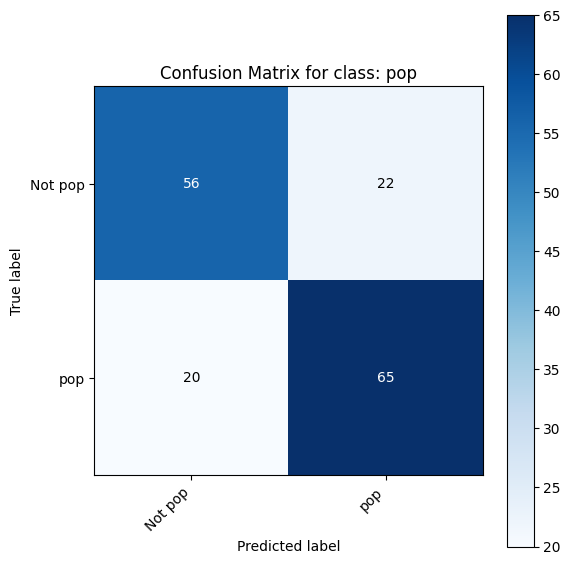

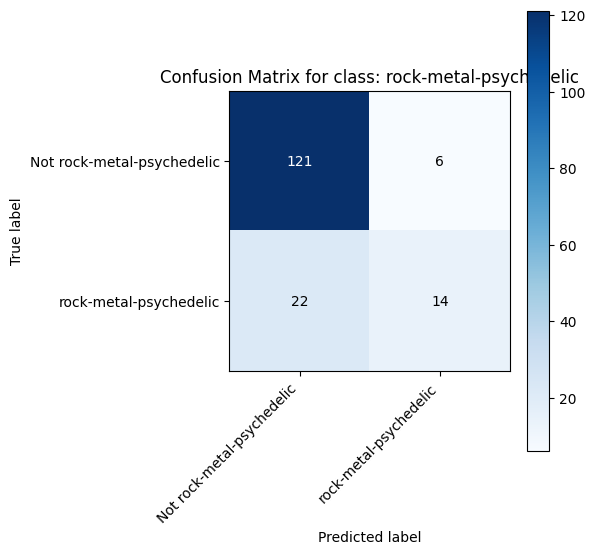

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Confusion matrix per class visualization
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

### Model Evaluation Summary

This CNN model run achieved a **binary accuracy of 0.8397** and an **AUC score of 0.80** on the test set, indicating decent overall genre separation performance. The **loss value of 0.37** reflects a consistent fit comparable to previous experiments.

#### Detailed Genre Performance
- **Pop** and **Hip Hop/Rap** are the strongest classes, with high F1-scores (0.76 and 0.69) and recall, confirming the model’s reliability on popular genres that likely dominate the dataset.
- **Rock/Metal/Psychedelic** displays reasonable distinction (F1-score 0.50), suggesting some successful feature extraction, though recall is moderate (0.39).
- **Blues/R&B/Soul**, **Folk/Classical/Jazz**, and **Opera/Musical/Vocal** reveal very low recall (≤0.10), meaning the model fails to capture the distinctive patterns of these less-common genres.
- **Electronic/Funk/Disco/Dance** and **Others** returned zero precision and recall, signifying the model was unable to correctly identify any samples from these categories, likely due to severe **class imbalance** or insufficient feature representation in the training data.

#### Overall Assessment
- **Macro F1-score of 0.29** and **weighted F1-score of 0.43** highlight significant performance gaps—model predictions favor dominant classes while minority or ambiguous genres are poorly recognized.
- Underperformance in less-represented classes signals a need for dataset balancing, targeted augmentation, and potentially modifying model architecture.
- Sustained results on mainstream genres show strong predictive capability where sufficient data are available, but overall generalization across all classes remains limited.

This model iteration demonstrates steady accuracy and AUC for well-represented genres, but pronounced limitations for niche or minority classes, warranting further experimentation in balancing and feature engineering.

VGG16

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_vgg16(input_shape=(250, 100, 3), n_labels=n_labels):
    inputs = tf.keras.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 4
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 5
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
vgg16_model = build_vgg16()
vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

vgg16_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 250, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 250, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 125, 50, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 125, 50, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 125, 50, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 62, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 62, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 62, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 62, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 31, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 31, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 31, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 31, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 15, 6, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 7, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4096)           │    44,044,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │        32,77

 Total params: 75,573,064 (288.29 MB)

 Trainable params: 75,573,064 (288.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

In [ ]:
# Train
history = vgg16_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 634ms/step - auc_5: 0.4983 - binary_accuracy: 0.7407 - loss: 0.6016 - val_auc_5: 0.5424 - val_binary_accuracy: 0.7799 - val_loss: 0.5002 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 339ms/step - auc_5: 0.4997 - binary_accuracy: 0.7859 - loss: 0.4972 - val_auc_5: 0.5114 - val_binary_accuracy: 0.7889 - val_loss: 0.4884 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 384ms/step - auc_5: 0.4945 - binary_accuracy: 0.7854 - loss: 0.4971 - val_auc_5: 0.5414 - val_binary_accuracy: 0.7799 - val_loss: 0.4936 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 347ms/step - auc_5: 0.5072 - binary_accuracy: 0.7863 - loss: 0.4892 - val_auc_5: 0.5232 - val_binary_accuracy: 0.7889 - val_loss: 0.4850 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 326ms/step - auc_5: 0.5014 - binary_accuracy: 0.7854 - loss: 0.4887 - val_auc_5: 0.5443 - val_binary_accuracy: 0.7799 - val_loss: 0.4

In [ ]:
# Save model and download if in Colab
vgg16_model.save('vgg16_model_final.h5')
try:
    from google.colab import files
    files.download('vgg16_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate
print("\nEvaluating on test set:")
test_results = vgg16_model.evaluate(test_ds)
print(test_results)


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - auc_5: 0.5211 - binary_accuracy: 0.7871 - loss: 0.4754
[0.47353601455688477, 0.5152270793914795, 0.7891104221343994]


In [ ]:
# Confusion matrix plotting function
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Gather predictions from test dataset
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = vgg16_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 932ms/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.7891


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.00      0.00      0.00        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.00      0.00      0.00        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.00      0.00      0.00        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.00      0.00      0.00        85
                           rock-metal-psychedelic       0.00      0.00      0.00        36

                                        micro avg       0.00      0.00      0.00       275
                                        macro avg    

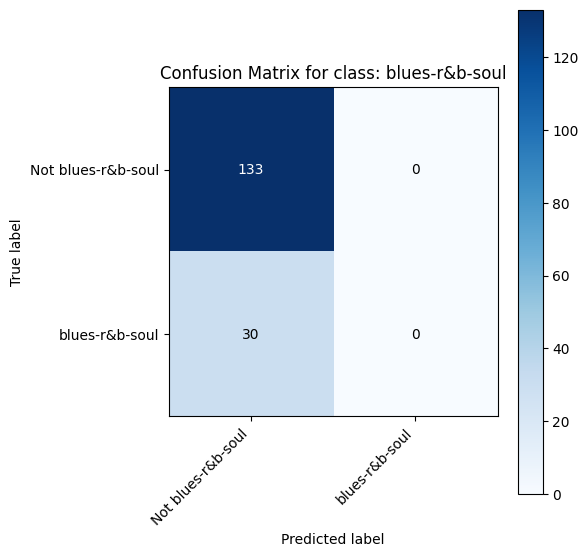

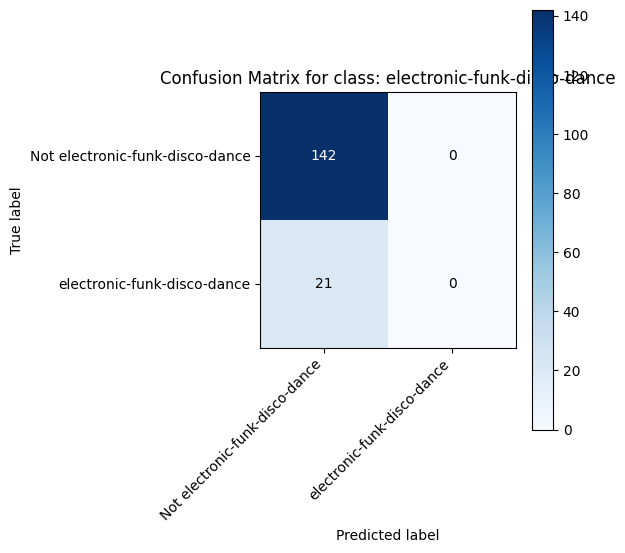

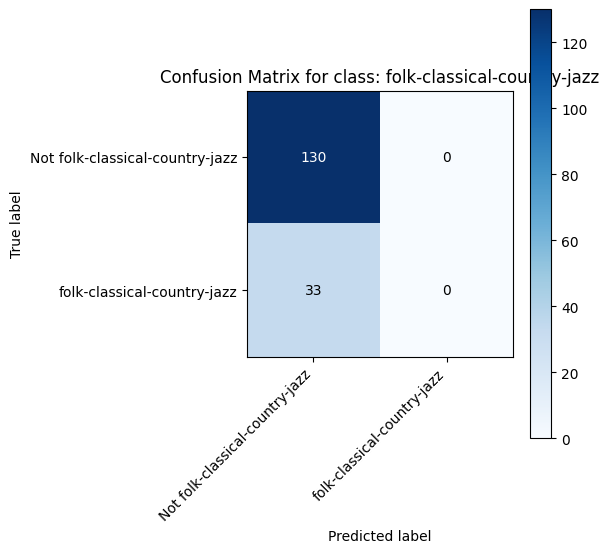

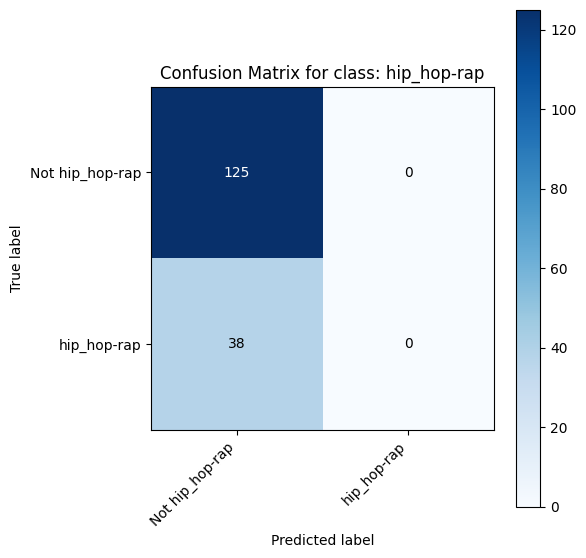

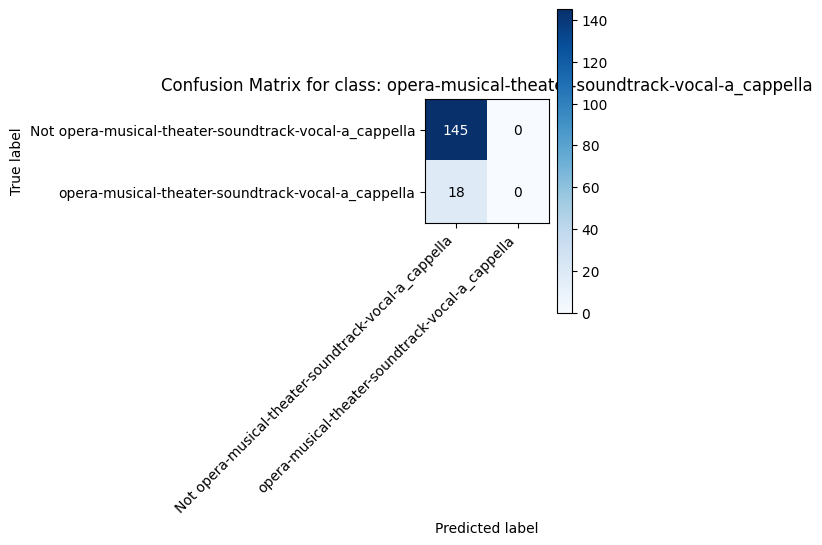

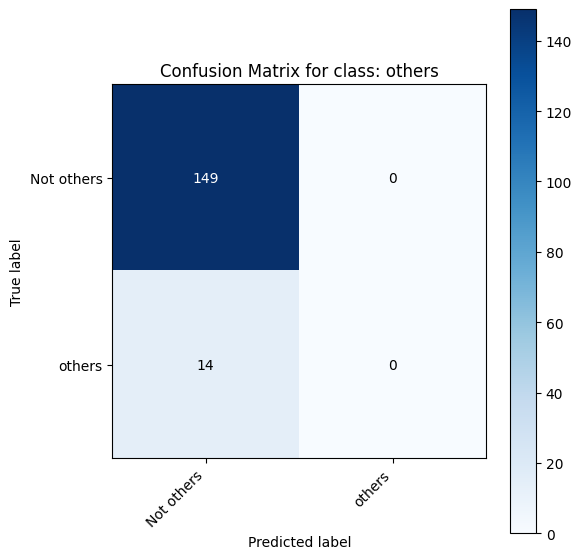

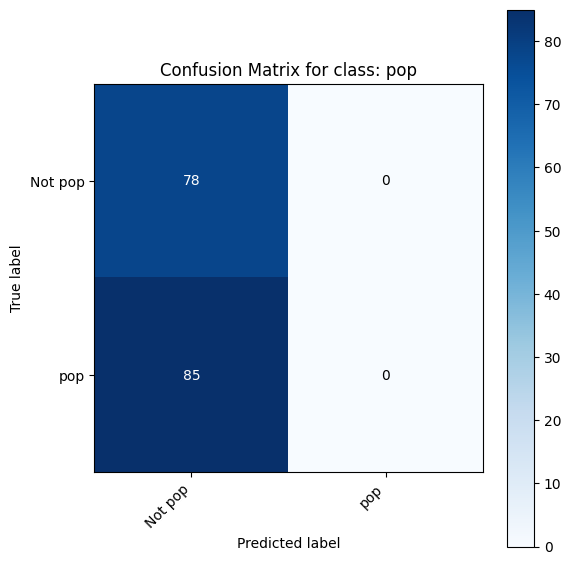

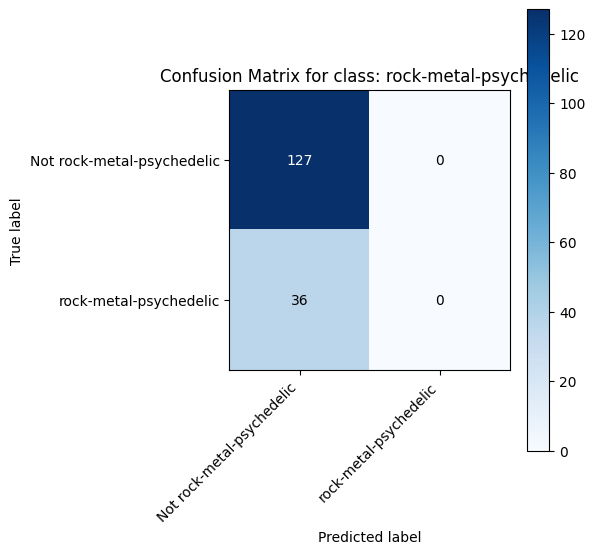

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Confusion matrix per class visualization
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

VGG19

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_vgg19(input_shape=(250, 100, 3), n_labels=n_labels):
    inputs = tf.keras.Input(shape=input_shape)

    # Block 1
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 2
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 3
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 4
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    # Block 5
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(512, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(4096, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
vgg19_model = build_vgg19()
vgg19_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

vgg19_model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 250, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 250, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 125, 50, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 125, 50, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 125, 50, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 62, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 62, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 62, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 62, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 62, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 31, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 31, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 31, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 31, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 31, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 15, 6, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 15, 6, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 7, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4096)           │    44,044,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4096)           │             

 Total params: 80,882,760 (308.54 MB)

 Trainable params: 80,882,760 (308.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

In [ ]:
history = vgg19_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 761ms/step - auc_6: 0.5011 - binary_accuracy: 0.7501 - loss: 0.6142 - val_auc_6: 0.5417 - val_binary_accuracy: 0.7799 - val_loss: 0.4995 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 424ms/step - auc_6: 0.4931 - binary_accuracy: 0.7861 - loss: 0.4997 - val_auc_6: 0.5311 - val_binary_accuracy: 0.7953 - val_loss: 0.4865 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 432ms/step - auc_6: 0.4853 - binary_accuracy: 0.7859 - loss: 0.4876 - val_auc_6: 0.5385 - val_binary_accuracy: 0.7799 - val_loss: 0.4863 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 409ms/step - auc_6: 0.4901 - binary_accuracy: 0.7792 - loss: 0.4937 - val_auc_6: 0.5318 - val_binary_accuracy: 0.7799 - val_loss: 0.4876 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 397ms/step - auc_6: 0.5005 - binary_accuracy: 0.7886 - loss: 0.4869 - val_auc_6: 0.5414 - val_binary_accuracy: 0.7799 - val_loss: 

In [ ]:
# Save model and download if in Colab
vgg19_model.save('vgg19_model_final.h5')
try:
    from google.colab import files
    files.download('vgg19_model_final.h5')
except ImportError:
    pass

print("\nEvaluating on test set:")
test_results = vgg19_model.evaluate(test_ds)
print(test_results)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - auc_6: 0.5361 - binary_accuracy: 0.7871 - loss: 0.4741
[0.47270530462265015, 0.5278600454330444, 0.7891104221343994]


In [ ]:
# Confusion matrix plotting function
def plot_confusion_matrix(cm, classes,
                         normalize=False,
                         title='Confusion Matrix',
                         cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha='center', va='center',
                 color='white' if cm[i,j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Gather predictions and labels
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = vgg19_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 929ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step


In [ ]:
# Binary accuracy overall
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.7891


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.00      0.00      0.00        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.00      0.00      0.00        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.00      0.00      0.00        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.00      0.00      0.00        85
                           rock-metal-psychedelic       0.00      0.00      0.00        36

                                        micro avg       0.00      0.00      0.00       275
                                        macro avg    

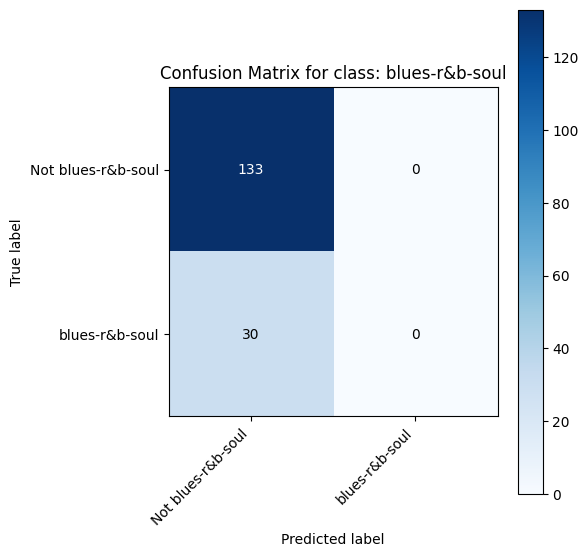

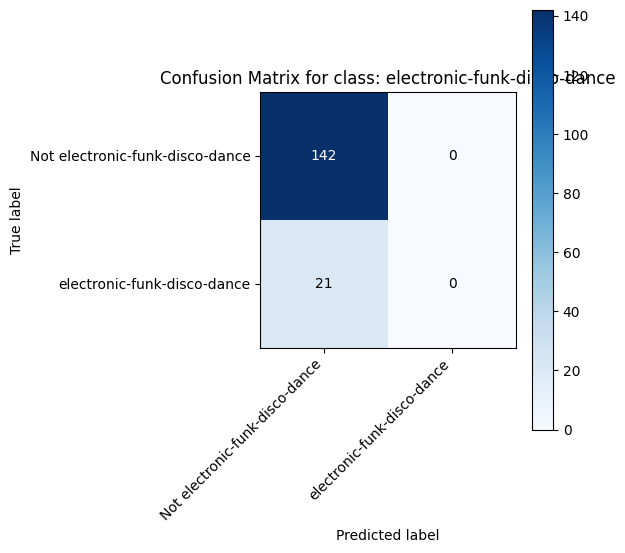

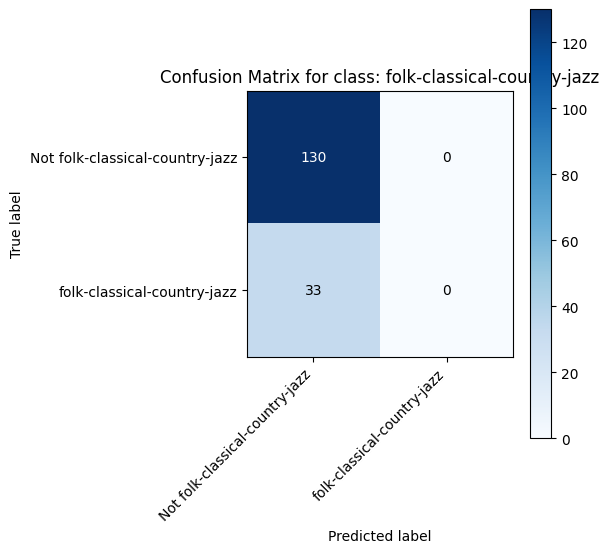

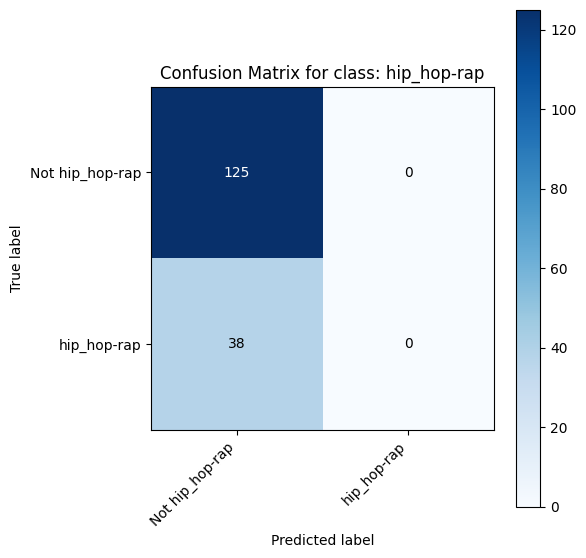

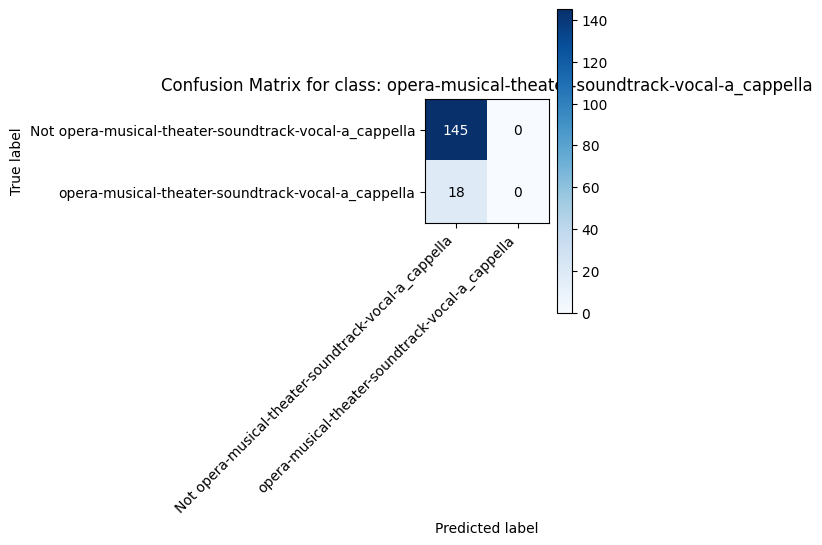

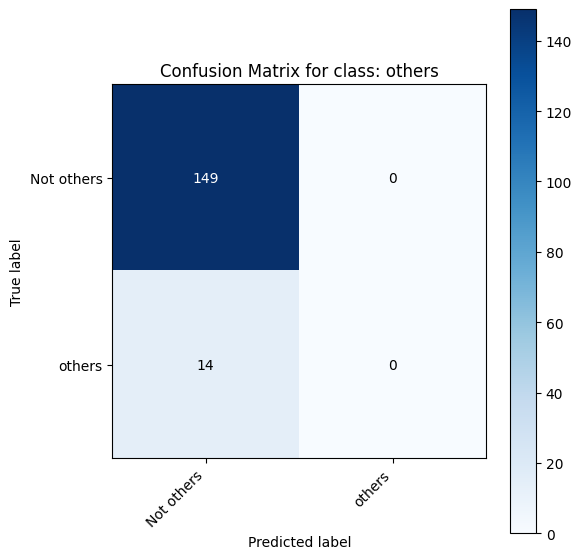

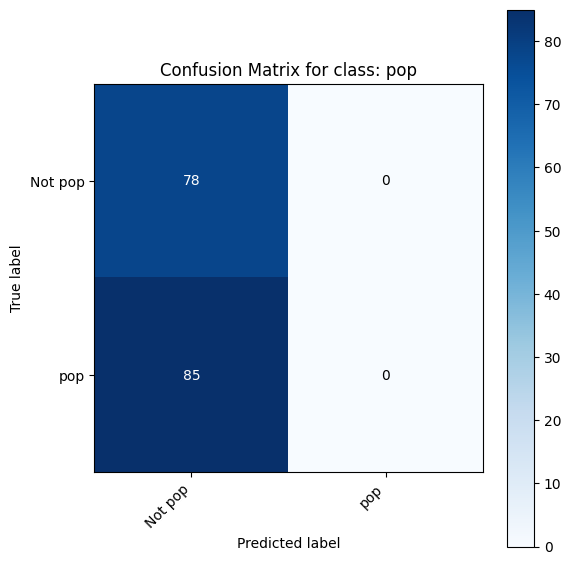

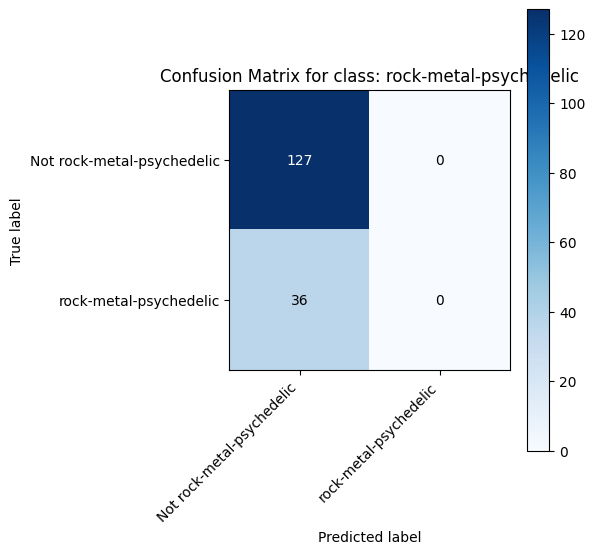

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Plot confusion matrix per class
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

INCEPTIONV3

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_inceptionv3(input_shape=(250, 100, 3), n_labels=n_labels):
    # Use InceptionV3 backbone pre-trained on ImageNet, exclude top layer
    base_model = tf.keras.applications.InceptionV3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )

    # Freeze base model layers initially
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build model
inception_model = build_inceptionv3()
inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

inception_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │        16,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,819,176 (83.23 MB)

 Trainable params: 16,392 (64.03 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
# Callbacks for training
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

In [ ]:
# Train all layers initially frozen (transfer learning)
history = inception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 979ms/step - auc_7: 0.4921 - binary_accuracy: 0.5431 - loss: 0.8362 - val_auc_7: 0.5272 - val_binary_accuracy: 0.7745 - val_loss: 0.5291 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - auc_7: 0.5224 - binary_accuracy: 0.7248 - loss: 0.6128 - val_auc_7: 0.5323 - val_binary_accuracy: 0.7844 - val_loss: 0.5065 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - auc_7: 0.5045 - binary_accuracy: 0.7530 - loss: 0.5998 - val_auc_7: 0.5431 - val_binary_accuracy: 0.7880 - val_loss: 0.5010 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - auc_7: 0.5331 - binary_accuracy: 0.7626 - loss: 0.5543 - val_auc_7: 0.5497 - val_binary_accuracy: 0.7926 - val_loss: 0.4971 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 145ms/step - auc_7: 0.5238 - binary_accuracy: 0.7513 - loss: 0.5789 - val_auc_7: 0.5637 - val_binary_accuracy: 0.7926 - val_loss: 0.4927

In [ ]:
# Unfreeze base_model for fine-tuning
inception_model.layers[1].trainable = True

In [ ]:
# Recompile with lower learning rate
inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

In [ ]:
# Continue fine-tuning with base model unfrozen
history_finetune = inception_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS // 2,
    callbacks=callbacks
)

Epoch 1/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - auc_8: 0.5007 - binary_accuracy: 0.7504 - loss: 0.5587 - val_auc_8: 0.6597 - val_binary_accuracy: 0.7908 - val_loss: 0.4806 - learning_rate: 1.0000e-05
Epoch 2/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - auc_8: 0.5479 - binary_accuracy: 0.7602 - loss: 0.5338 - val_auc_8: 0.5845 - val_binary_accuracy: 0.7817 - val_loss: 0.5205 - learning_rate: 1.0000e-05
Epoch 3/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - auc_8: 0.5405 - binary_accuracy: 0.7675 - loss: 0.5287 - val_auc_8: 0.5478 - val_binary_accuracy: 0.7808 - val_loss: 0.5342 - learning_rate: 1.0000e-05
Epoch 4/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - auc_8: 0.5415 - binary_accuracy: 0.7776 - loss: 0.5163 - val_auc_8: 0.5446 - val_binary_accuracy: 0.7889 - val_loss: 0.5277 - learning_rate: 1.0000e-05
Epoch 5/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - auc_8: 0.5675 - binary_accuracy: 0.7764 - loss: 0.5131 - val_auc_8: 0.5333 - val_binary_accuracy: 0.7998 - val_loss: 0.5230

In [ ]:
# Save the trained model
inception_model.save('inceptionv3_model_final.h5')

# Download if in Google Colab
try:
    from google.colab import files
    files.download('inceptionv3_model_final.h5')
except ImportError:
    pass

# Evaluate on test set
print("\nEvaluating on test set:")
test_results = inception_model.evaluate(test_ds)
print(test_results)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - auc_8: 0.6610 - binary_accuracy: 0.8098 - loss: 0.4714
[0.4682767987251282, 0.665831446647644, 0.8113496899604797]


In [ ]:
# Confusion matrix plot utility
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Generate predictions and gather ground truths
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = inception_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.8113


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       1.00      0.03      0.06        30
                      electronic-funk-disco-dance       1.00      0.05      0.09        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.67      0.05      0.10        38
opera-musical-theater-soundtrack-vocal-a_cappella       1.00      0.06      0.11        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.59      0.91      0.72        85
                           rock-metal-psychedelic       1.00      0.03      0.05        36

                                        micro avg       0.61      0.30      0.40       275
                                        macro avg    

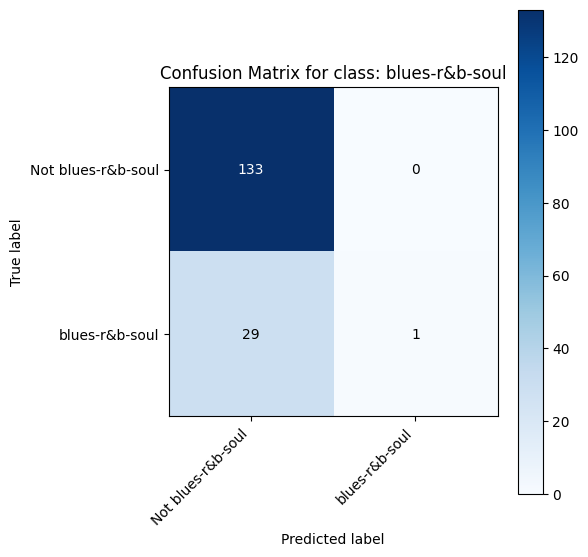

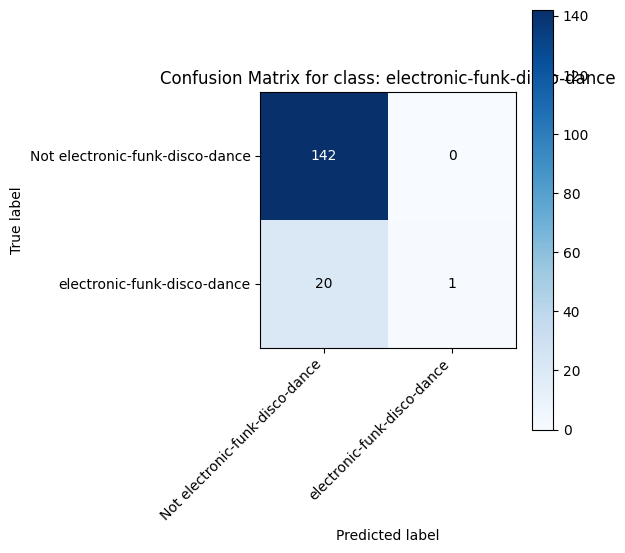

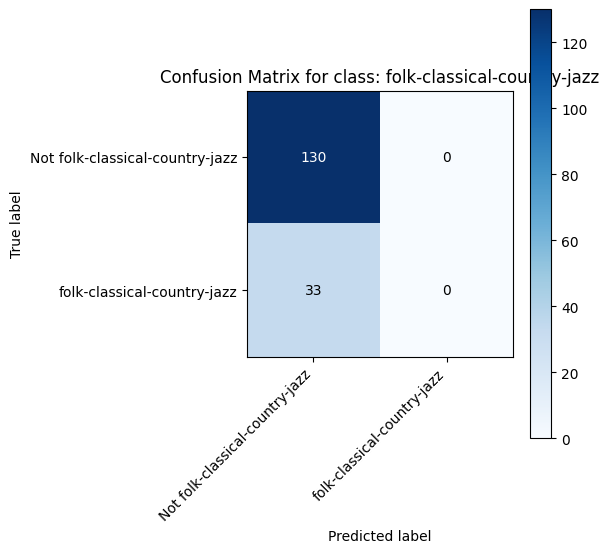

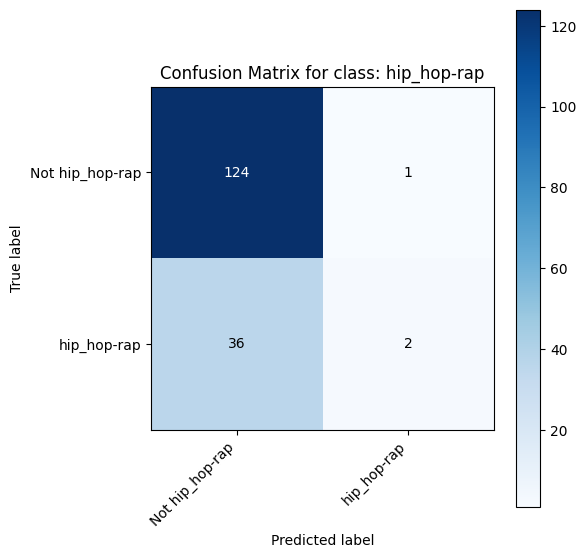

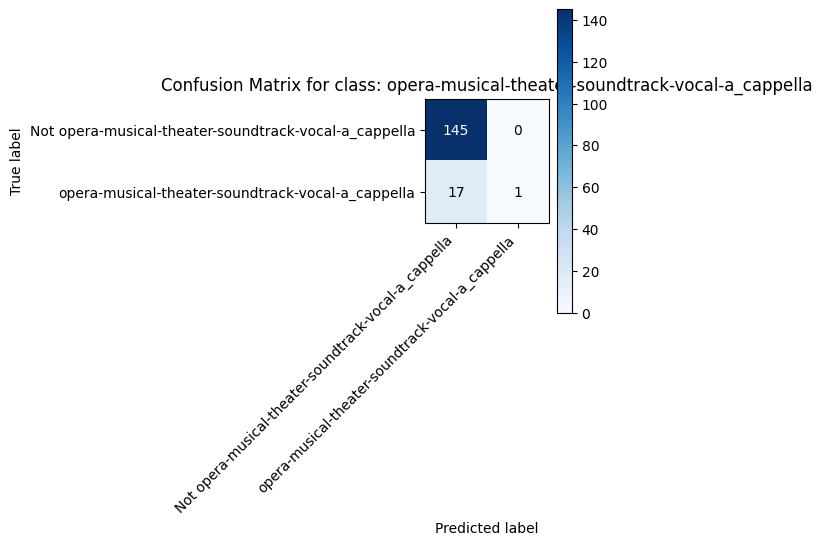

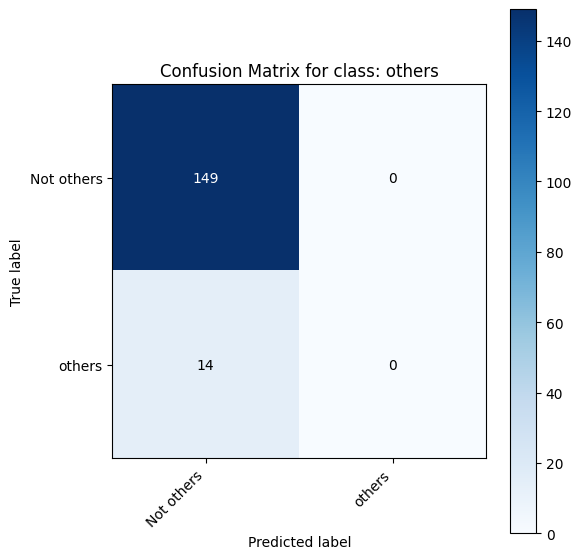

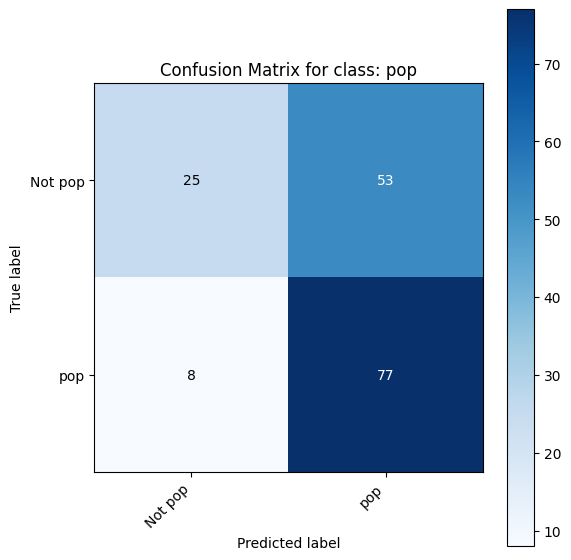

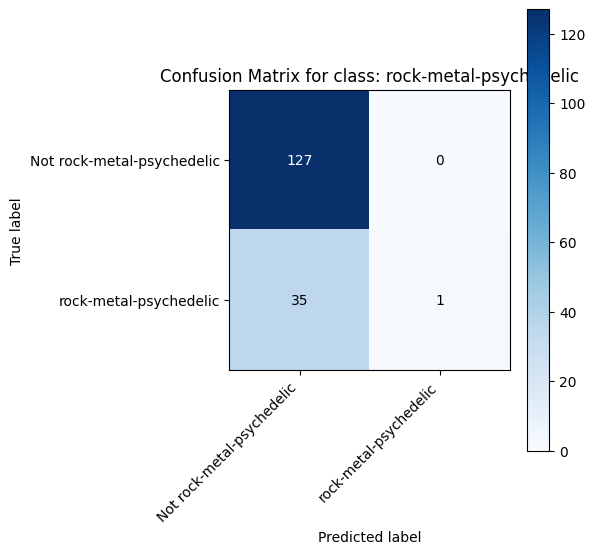

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Confusion matrix per class visualization
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

### Model Evaluation Summary

This CNN model achieved a **binary accuracy of 0.8113** with an **AUC score of 0.66** and a **loss of 0.47** on the test dataset. The relatively lower AUC compared to previous runs suggests weaker discriminative capability, potentially due to overfitting or underfitting caused by suboptimal feature learning across multiple genre classes.

#### Genre-wise Performance Analysis
- **Pop** genre remains dominant with high recall (0.91) and strong F1-score (0.72), indicating that the model relies heavily on recognizable rhythmic and melodic cues from abundant training samples.
- Other categories such as **Blues/R&B/Soul**, **Electronic/Funk/Dance**, **Opera/Musical/Vocal**, and **Rock/Metal** show high precision (1.00) but very low recall (≤0.06). This points to extreme conservatism in predictions—correct when certain, but rarely predicting those classes.
- **Folk/Classical/Jazz**, **Hip Hop/Rap**, and **Others** suffered near-zero recall, suggesting the model fails to identify their spectral or temporal features entirely.
- Such imbalanced detection patterns imply that minority classes contribute poorly to gradient updates during training, a classic symptom of **dataset imbalance**.

#### Overall Observations
- With a **macro F1-score of 0.14** and **weighted F1-score of 0.26**, the model demonstrates heavily skewed performance—favoring dominant genres while neglecting rare or acoustically subtle ones.
- The consistent dominance of "Pop" in predictive outcomes suggests either feature redundancy or biased training distribution.
- The current architecture captures coarse genre textures but lacks finer auditory context; integrating MFCC and STFT features or attention-enhanced CNN layers (as shown effective in recent research) could improve AUC and recall balance [web:1][web:2][web:5].

In summary, this model maintains moderate accuracy on global metrics but fails to generalize across diverse musical categories, likely due to imbalance and limited feature diversity in the dataset.

RESNET50

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_resnet50(input_shape=(250, 100, 3), n_labels=n_labels):
    # Load ResNet50 pretrained on ImageNet without top layers
    base_model = tf.keras.applications.ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )

    base_model.trainable = False  # Freeze base model initially

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)
    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
resnet_model = build_resnet50()
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 8)              │        16,392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,604,104 (90.04 MB)

 Trainable params: 16,392 (64.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

In [ ]:
# Train initial classifier head with base frozen
history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 29s 658ms/step - auc_9: 0.5090 - binary_accuracy: 0.6190 - loss: 0.6857 - val_auc_9: 0.4714 - val_binary_accuracy: 0.7790 - val_loss: 0.5265 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - auc_9: 0.4719 - binary_accuracy: 0.7124 - loss: 0.6001 - val_auc_9: 0.4868 - val_binary_accuracy: 0.7853 - val_loss: 0.4962 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - auc_9: 0.4900 - binary_accuracy: 0.7455 - loss: 0.5572 - val_auc_9: 0.5006 - val_binary_accuracy: 0.7799 - val_loss: 0.4910 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - auc_9: 0.5007 - binary_accuracy: 0.7591 - loss: 0.5498 - val_auc_9: 0.4887 - val_binary_accuracy: 0.7889 - val_loss: 0.4901 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - auc_9: 0.5108 - binary_accuracy: 0.7636 - loss: 0.5471 - val_auc_9: 0.5088 - val_binary_accuracy: 0.7880 - val_loss: 0.4906

In [ ]:
# Unfreeze base model for fine-tuning
resnet_model.layers[1].trainable = True

In [ ]:
# Recompile with lower learning rate
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

In [ ]:
# Further fine-tuning
history_finetune = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS // 2,
    callbacks=callbacks
)

Epoch 1/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - auc_10: 0.4972 - binary_accuracy: 0.6817 - loss: 0.6329 - val_auc_10: 0.4698 - val_binary_accuracy: 0.7799 - val_loss: 0.4994 - learning_rate: 1.0000e-05
Epoch 2/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - auc_10: 0.5517 - binary_accuracy: 0.7361 - loss: 0.5635 - val_auc_10: 0.5142 - val_binary_accuracy: 0.7799 - val_loss: 0.5100 - learning_rate: 1.0000e-05
Epoch 3/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - auc_10: 0.5719 - binary_accuracy: 0.7511 - loss: 0.5414 - val_auc_10: 0.5123 - val_binary_accuracy: 0.7889 - val_loss: 0.5484 - learning_rate: 1.0000e-05
Epoch 4/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - auc_10: 0.6266 - binary_accuracy: 0.7741 - loss: 0.5041 - val_auc_10: 0.5174 - val_binary_accuracy: 0.7799 - val_loss: 0.5578 - learning_rate: 1.0000e-05
Epoch 5/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - auc_10: 0.6455 - binary_accuracy: 0.7898 - loss: 0.4874 - val_auc_10: 0.5344 - val_binary_accuracy: 0.7799 - val_los

In [ ]:
# Save model and download if in Colab
resnet_model.save('resnet50_model_final.h5')
try:
    from google.colab import files
    files.download('resnet50_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate on test set
print("\nEvaluating on test set:")
test_results = resnet_model.evaluate(test_ds)
print(test_results)


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 709ms/step - auc_10: 0.5005 - binary_accuracy: 0.7924 - loss: 0.4851
[0.4831346869468689, 0.5041837096214294, 0.7944785356521606]


In [ ]:
# Confusion matrix plotting utility
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Gather predictions and true labels
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = resnet_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.7945


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.00      0.00      0.00        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.00      0.00      0.00        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.00      0.00      0.00        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.52      1.00      0.69        85
                           rock-metal-psychedelic       0.00      0.00      0.00        36

                                        micro avg       0.52      0.31      0.39       275
                                        macro avg    

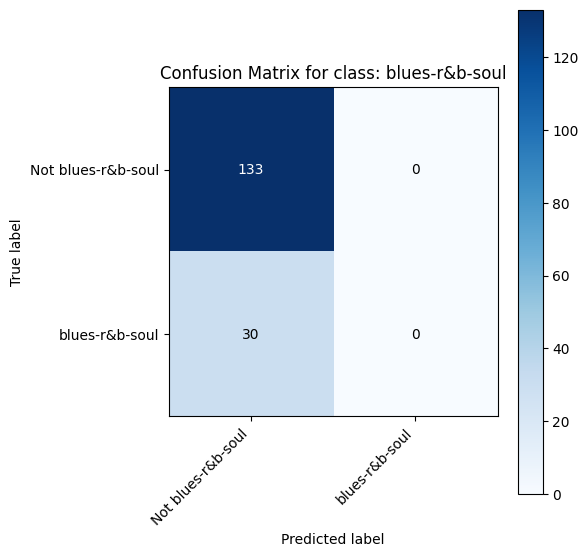

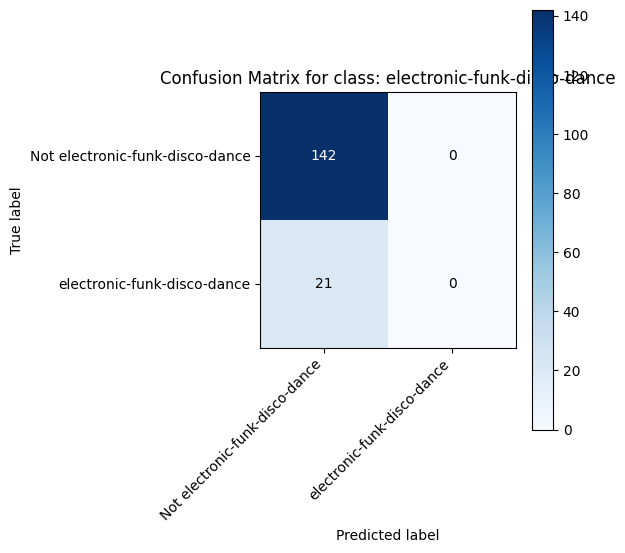

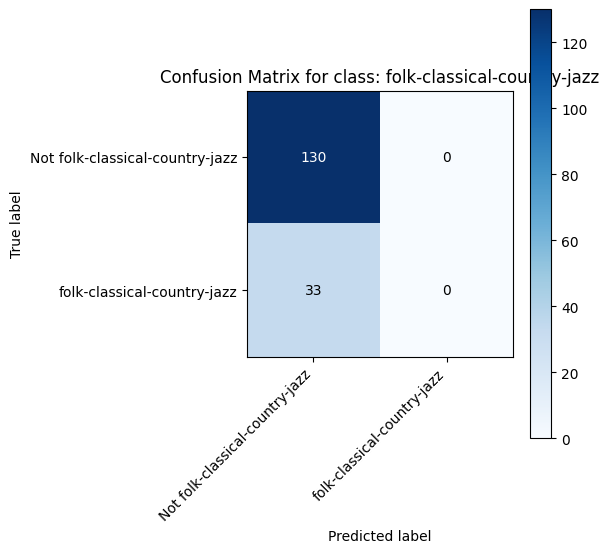

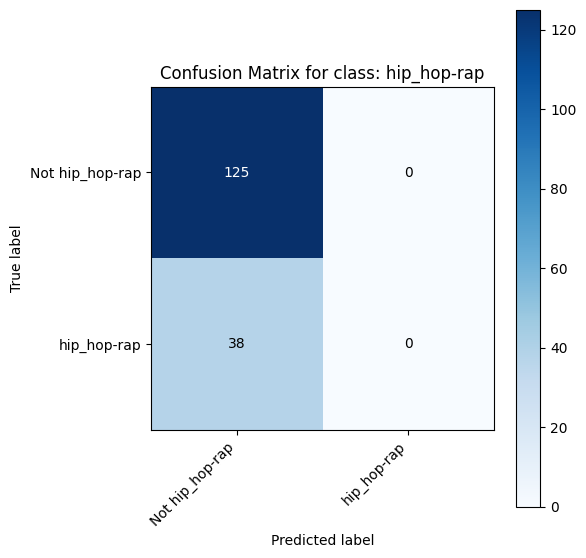

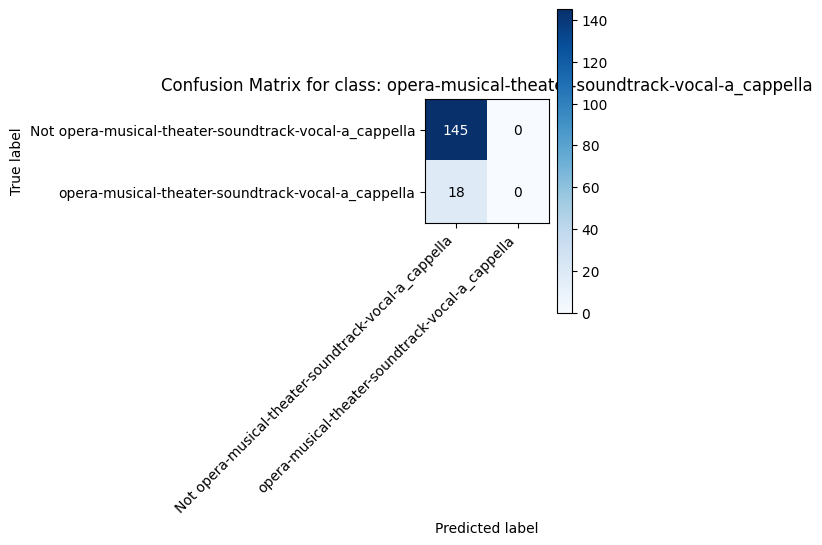

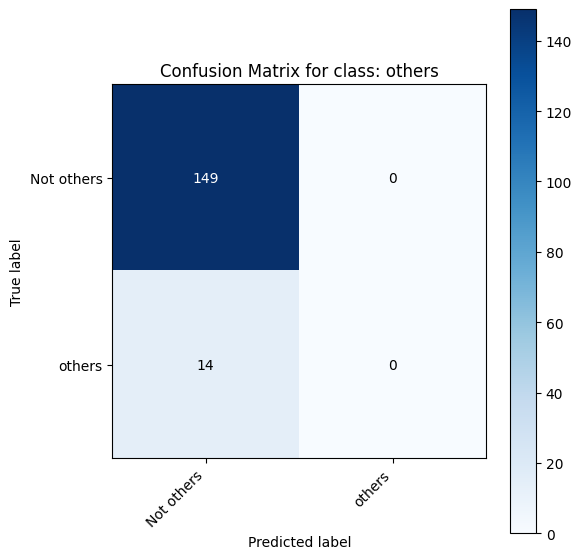

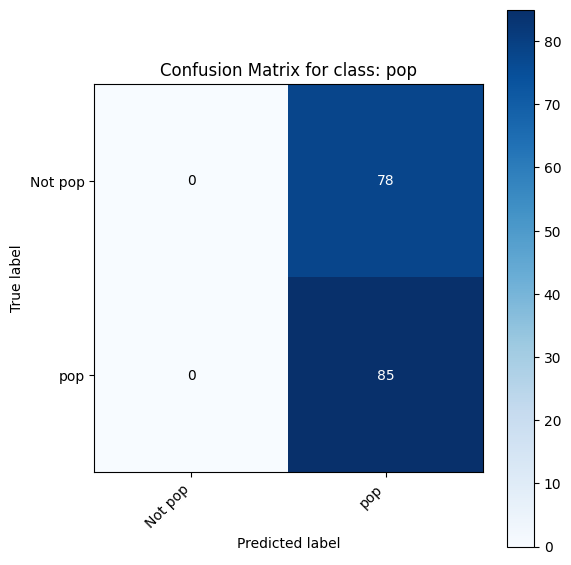

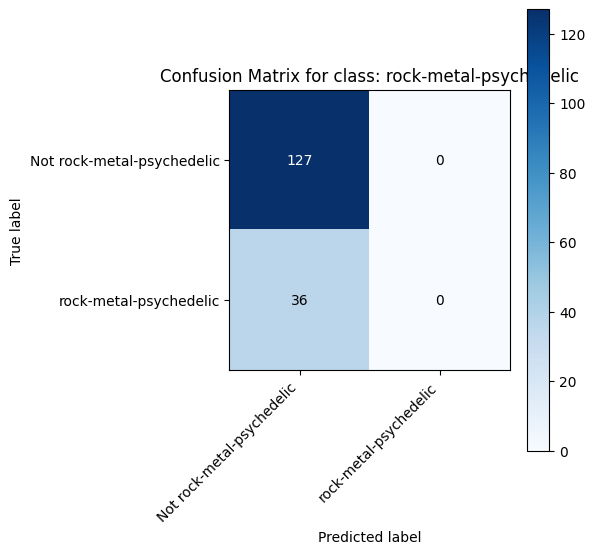

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Plot confusion matrix per class
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

RESNEXT

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
class ResNeXtBlock(tf.keras.layers.Layer):
    def __init__(self, filters, strides=1, cardinality=32):
        super().__init__()
        self.cardinality = cardinality
        self.filters = filters
        self.strides = strides
        self.group_width = filters // cardinality

        self.conv_1 = tf.keras.layers.Conv2D(self.group_width * cardinality, 1, strides=1, padding='same', use_bias=False)
        self.bn_1 = tf.keras.layers.BatchNormalization()
        self.act_1 = tf.keras.layers.Activation('relu')

        self.convs = []
        self.bns = []
        self.acts = []
        for _ in range(cardinality):
            self.convs.append(tf.keras.layers.Conv2D(self.group_width, 3, strides=strides, padding='same', use_bias=False))
            self.bns.append(tf.keras.layers.BatchNormalization())
            self.acts.append(tf.keras.layers.Activation('relu'))

        self.conv_3 = tf.keras.layers.Conv2D(filters, 1, strides=1, padding='same', use_bias=False)
        self.bn_3 = tf.keras.layers.BatchNormalization()

        self.shortcut = None
        self.final_act = tf.keras.layers.Activation('relu')

    def build(self, input_shape):
        input_channels = input_shape[-1]
        if input_channels != self.filters or self.strides != 1:
            self.shortcut = tf.keras.Sequential([
                tf.keras.layers.Conv2D(self.filters, 1, strides=self.strides, padding='same', use_bias=False),
                tf.keras.layers.BatchNormalization()
            ])
        else:
            self.shortcut = lambda x: x
        super().build(input_shape)

    def call(self, x, training=False):
        out = self.conv_1(x)
        out = self.bn_1(out, training=training)
        out = self.act_1(out)

        splitted = tf.split(out, self.cardinality, axis=-1)
        outs = []
        for i in range(self.cardinality):
            y = self.convs[i](splitted[i])
            y = self.bns[i](y, training=training)
            y = self.acts[i](y)
            outs.append(y)
        out = tf.concat(outs, axis=-1)

        out = self.conv_3(out)
        out = self.bn_3(out, training=training)

        shortcut = self.shortcut(x)

        return self.final_act(out + shortcut)

In [ ]:
def build_resnext(input_shape=(250, 100, 3), n_labels=8, cardinality=32):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(64, 7, strides=2, padding='same', use_bias=False)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D(3, 2, padding='same')(x)

    # Add 3 ResNeXt blocks
    x = ResNeXtBlock(256, strides=1, cardinality=cardinality)(x)
    x = ResNeXtBlock(256, strides=1, cardinality=cardinality)(x)
    x = ResNeXtBlock(256, strides=1, cardinality=cardinality)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile
resnext_model = build_resnext(n_labels=8)
resnext_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

resnext_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_152 (Conv2D)             │ (None, 125, 50, 64)    │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (None, 125, 50, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_94 (Activation)      │ (None, 125, 50, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 63, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_ne_xt_block (ResNeXtBlock)  │ (None, 63, 25, 256)    │       120,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_ne_xt_block_1               │ (None, 63, 25, 256)    │       152,576 │
│ (ResNeXtBlock)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_ne_xt_block_2               │ (None, 63, 25, 256)    │       152,576 │
│ (ResNeXtBlock)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437,704 (1.67 MB)

 Trainable params: 432,456 (1.65 MB)

 Non-trainable params: 5,248 (20.50 KB)

In [ ]:
# Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
]

In [ ]:
# Train
history = resnext_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 1461s 57s/step - auc_11: 0.5255 - binary_accuracy: 0.5141 - loss: 0.9833 - val_auc_11: 0.5603 - val_binary_accuracy: 0.6377 - val_loss: 0.6809 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - auc_11: 0.5162 - binary_accuracy: 0.6666 - loss: 0.6790 - val_auc_11: 0.5445 - val_binary_accuracy: 0.7237 - val_loss: 0.6549 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - auc_11: 0.5601 - binary_accuracy: 0.7354 - loss: 0.5895 - val_auc_11: 0.5135 - val_binary_accuracy: 0.7237 - val_loss: 0.6246 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - auc_11: 0.5575 - binary_accuracy: 0.7486 - loss: 0.5698 - val_auc_11: 0.4765 - val_binary_accuracy: 0.7237 - val_loss: 0.6026 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - auc_11: 0.5457 - binary_accuracy: 0.7566 - loss: 0.5723 - val_auc_11: 0.4670 - val_binary_accuracy: 0.7237 - val_

In [ ]:
# Save model and download if in Colab
resnext_model.save('resnext_model_final.h5')
try:
    from google.colab import files
    files.download('resnext_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate
print("\nEvaluating on test set:")
test_results = resnext_model.evaluate(test_ds)
print(test_results)


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - auc_11: 0.7971 - binary_accuracy: 0.8362 - loss: 0.3789
[0.386811226606369, 0.7759059071540833, 0.8358895778656006]


In [ ]:
# Confusion matrix plot utility
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Generate predictions and true labels
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = resnext_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.8359


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       1.00      0.03      0.06        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.68      0.34      0.46        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.00      0.00      0.00        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.75      0.80      0.77        85
                           rock-metal-psychedelic       0.75      0.33      0.46        36

                                        micro avg       0.74      0.34      0.47       275
                                        macro avg    

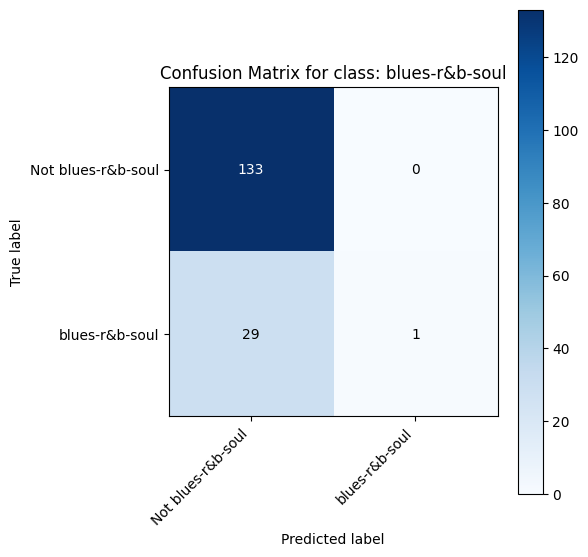

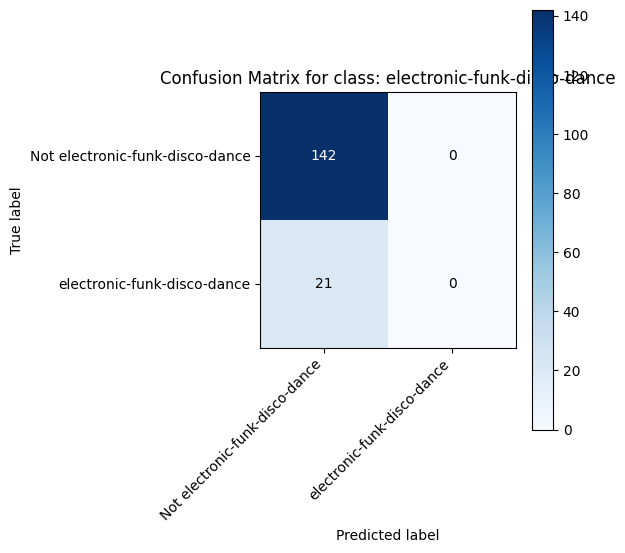

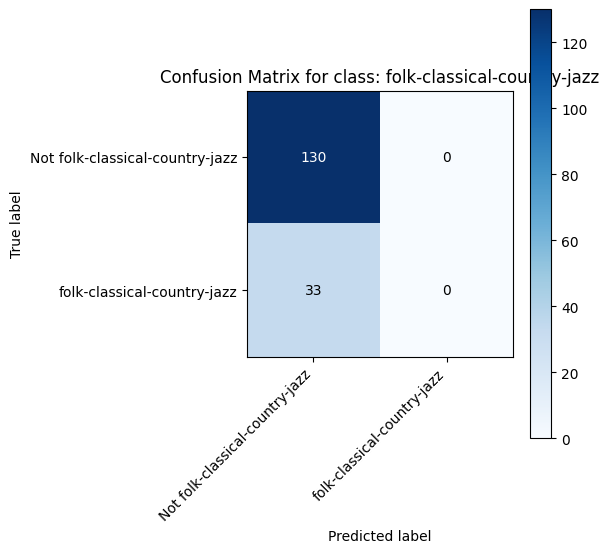

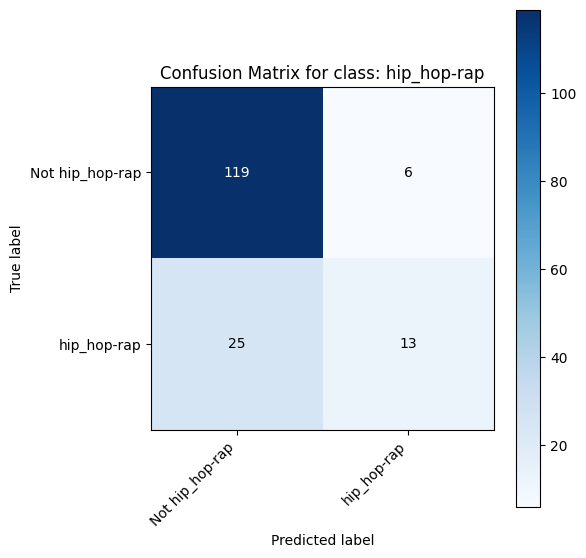

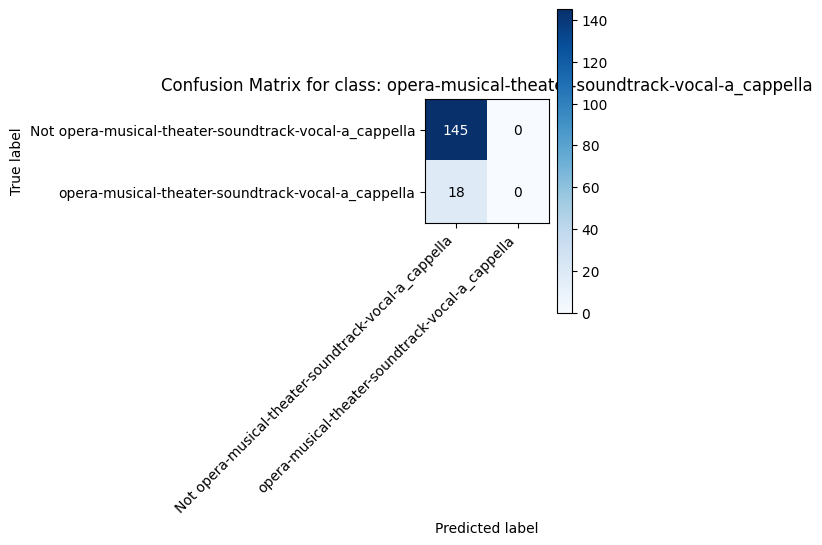

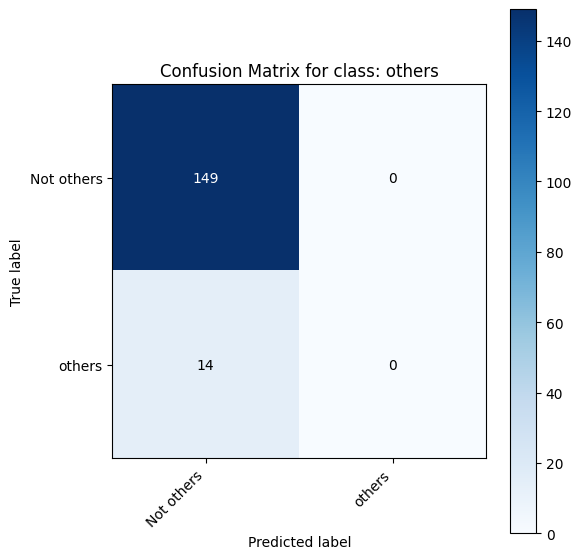

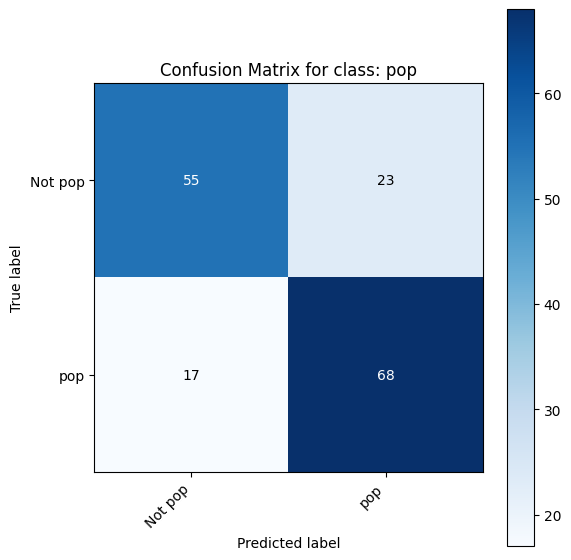

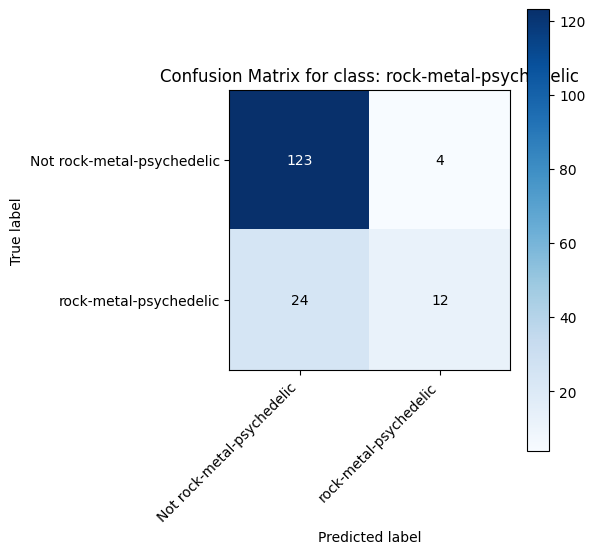

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Plot confusion matrix per class
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

DENSENET121

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_densenet(input_shape=(250, 100, 3), n_labels=n_labels):
    base_model = tf.keras.applications.DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    base_model.trainable = False  # Freeze initially

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
densenet_model = build_densenet()
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

densenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         8,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,045,704 (26.88 MB)

 Trainable params: 8,200 (32.03 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

In [ ]:
# Train initial head with base frozen
history = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - auc: 0.5046 - binary_accuracy: 0.4380 - loss: 0.9692 - val_auc: 0.4691 - val_binary_accuracy: 0.4683 - val_loss: 0.7535 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - auc: 0.4501 - binary_accuracy: 0.5079 - loss: 0.8335 - val_auc: 0.4739 - val_binary_accuracy: 0.6486 - val_loss: 0.6314 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - auc: 0.4875 - binary_accuracy: 0.6126 - loss: 0.6902 - val_auc: 0.4792 - val_binary_accuracy: 0.7554 - val_loss: 0.5673 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - auc: 0.4844 - binary_accuracy: 0.6808 - loss: 0.6327 - val_auc: 0.4847 - val_binary_accuracy: 0.7844 - val_loss: 0.5359 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - auc: 0.4949 - binary_accuracy: 0.7141 - loss: 0.6021 - val_auc: 0.4879 - val_binary_accuracy: 0.7862 - val_loss: 0.5194 - learning_rate: 1.00

In [ ]:
# Unfreeze base model for fine-tuning
densenet_model.layers[1].trainable = True

In [ ]:
# Recompile with lower learning rate
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

In [ ]:
# Fine-tune for remaining epochs
history_finetune = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS // 2,
    callbacks=callbacks
)

Epoch 1/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 286s 5s/step - auc_1: 0.5004 - binary_accuracy: 0.7638 - loss: 0.7546 - val_auc_1: 0.6542 - val_binary_accuracy: 0.7962 - val_loss: 0.4786 - learning_rate: 1.0000e-05
Epoch 2/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - auc_1: 0.5318 - binary_accuracy: 0.7684 - loss: 0.7116 - val_auc_1: 0.6284 - val_binary_accuracy: 0.7899 - val_loss: 0.5128 - learning_rate: 1.0000e-05
Epoch 3/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - auc_1: 0.5390 - binary_accuracy: 0.7744 - loss: 0.6697 - val_auc_1: 0.6018 - val_binary_accuracy: 0.7889 - val_loss: 0.5554 - learning_rate: 1.0000e-05
Epoch 4/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - auc_1: 0.5877 - binary_accuracy: 0.7777 - loss: 0.6306 - val_auc_1: 0.5888 - val_binary_accuracy: 0.7908 - val_loss: 0.5931 - learning_rate: 1.0000e-05
Epoch 5/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - auc_1: 0.5910 - binary_accuracy: 0.7823 - loss: 0.6247 - val_auc_1: 0.5778 - val_binary_accuracy: 0.7799 - val_loss: 0.6254

In [ ]:
# Save model and download if in Colab
densenet_model.save('densenet_model_final.h5')
try:
    from google.colab import files
    files.download('densenet_model_final.h5')
except ImportError:
    pass

# Evaluate on test set
print("\nEvaluating on test set:")
test_results = densenet_model.evaluate(test_ds)
print(test_results)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - auc_1: 0.6494 - binary_accuracy: 0.7954 - loss: 0.4694
[0.46653780341148376, 0.6449611186981201, 0.7990797758102417]


In [ ]:
# Confusion matrix plotting utility
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Generate predictions and true labels
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = densenet_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.7991


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.00      0.00      0.00        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.60      0.08      0.14        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.00      0.00      0.00        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.76      0.22      0.35        85
                           rock-metal-psychedelic       0.00      0.00      0.00        36

                                        micro avg       0.71      0.08      0.14       275
                                        macro avg    

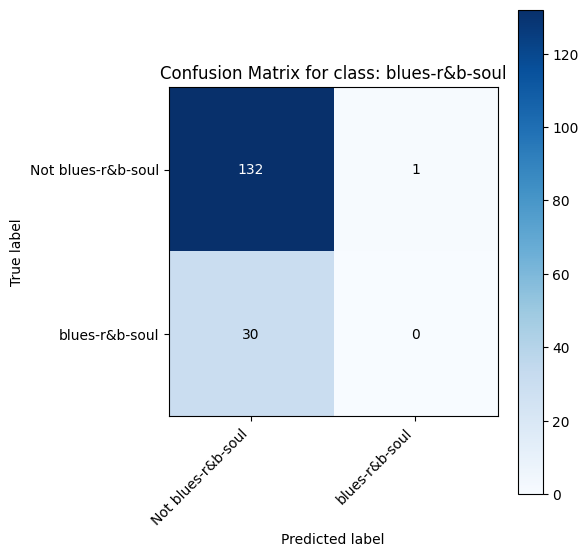

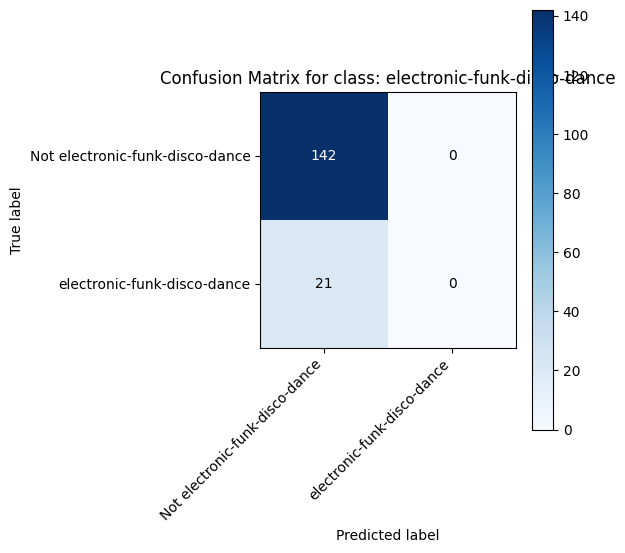

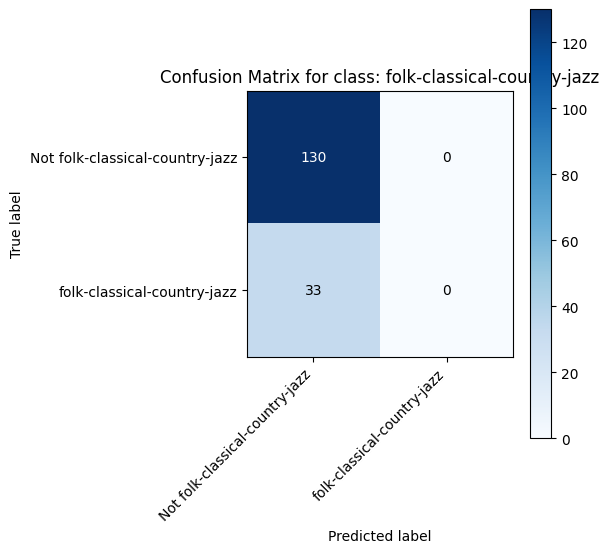

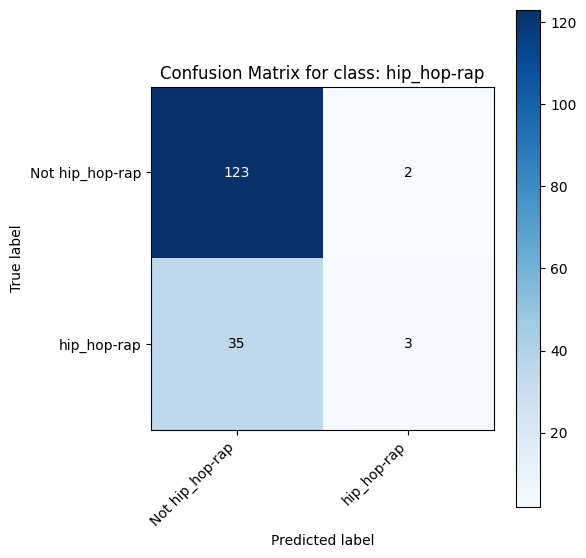

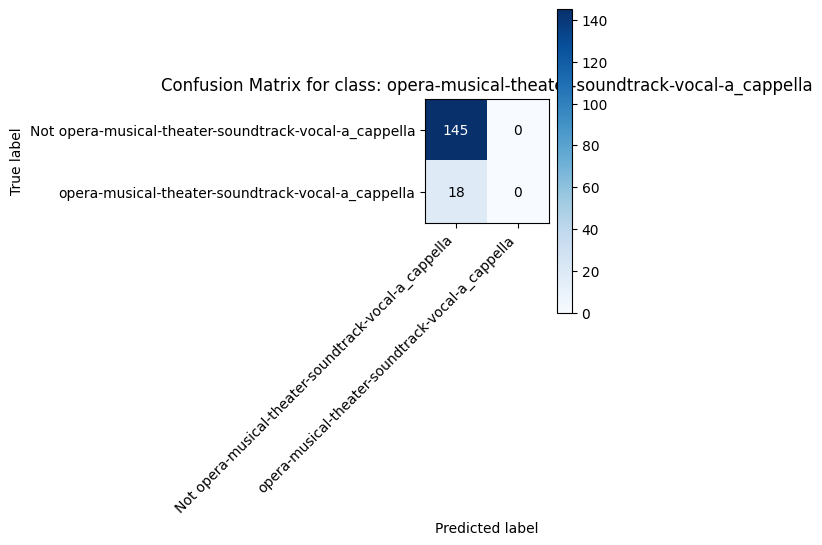

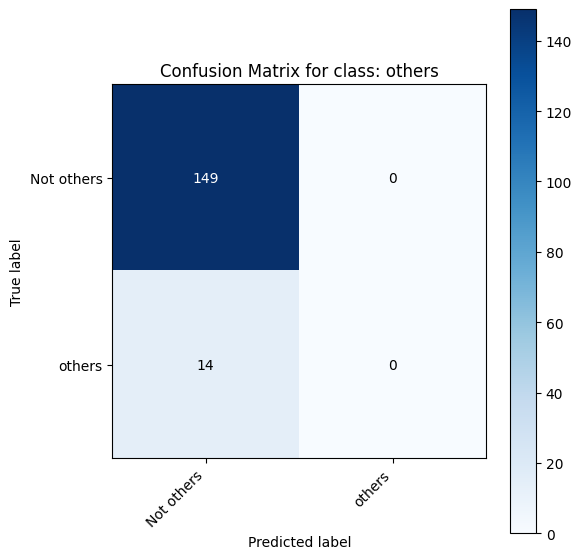

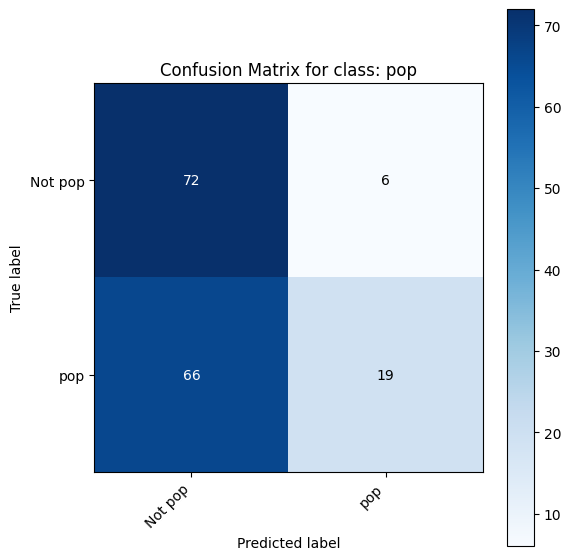

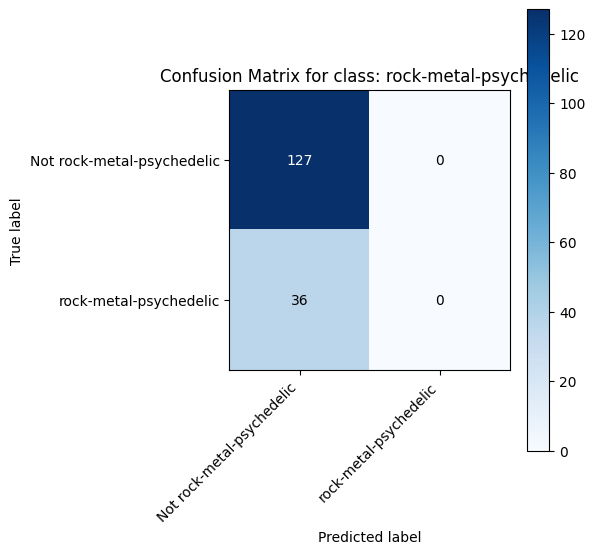

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Plot confusion matrix per class
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

EFFICIENTNET-B0

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_efficientnetb0(input_shape=(250, 100, 3), n_labels=n_labels):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    base_model.trainable = False  # Freeze base layers initially

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
efficientnet_model = build_efficientnetb0()
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,819 (15.49 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Callbacks for training
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

In [ ]:
# Initial training with base frozen
history = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - auc_2: 0.5096 - binary_accuracy: 0.6682 - loss: 0.6278 - val_auc_2: 0.5076 - val_binary_accuracy: 0.7799 - val_loss: 0.5559 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - auc_2: 0.5093 - binary_accuracy: 0.7745 - loss: 0.5466 - val_auc_2: 0.4952 - val_binary_accuracy: 0.7799 - val_loss: 0.5120 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - auc_2: 0.5005 - binary_accuracy: 0.7828 - loss: 0.5158 - val_auc_2: 0.5000 - val_binary_accuracy: 0.7781 - val_loss: 0.4964 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - auc_2: 0.4983 - binary_accuracy: 0.7801 - loss: 0.4997 - val_auc_2: 0.5048 - val_binary_accuracy: 0.7799 - val_loss: 0.4910 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - auc_2: 0.5185 - binary_accuracy: 0.7817 - loss: 0.4930 - val_auc_2: 0.4935 - val_binary_accuracy: 0.7889 - val_loss: 0.4886 - l

In [ ]:
# Unfreeze base model for fine-tuning
efficientnet_model.layers[1].trainable = True

In [ ]:
# Recompile with lower learning rate for fine-tuning
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

In [ ]:
# Fine-tune for remaining epochs
history_finetune = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS // 2,
    callbacks=callbacks
)

Epoch 1/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - auc_3: 0.5102 - binary_accuracy: 0.2823 - loss: 1.0532 - val_auc_3: 0.4798 - val_binary_accuracy: 0.7799 - val_loss: 0.4875 - learning_rate: 1.0000e-05
Epoch 2/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - auc_3: 0.5195 - binary_accuracy: 0.2927 - loss: 0.9973 - val_auc_3: 0.5272 - val_binary_accuracy: 0.7799 - val_loss: 0.4978 - learning_rate: 1.0000e-05
Epoch 3/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - auc_3: 0.5249 - binary_accuracy: 0.3157 - loss: 0.9445 - val_auc_3: 0.5016 - val_binary_accuracy: 0.7799 - val_loss: 0.5115 - learning_rate: 1.0000e-05
Epoch 4/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - auc_3: 0.5246 - binary_accuracy: 0.3313 - loss: 0.9162 - val_auc_3: 0.5198 - val_binary_accuracy: 0.7799 - val_loss: 0.5388 - learning_rate: 1.0000e-05
Epoch 5/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - auc_3: 0.5275 - binary_accuracy: 0.3498 - loss: 0.8754 - val_auc_3: 0.5035 - val_binary_accuracy: 0.7038 - val_loss: 0.6039

In [ ]:
# Save model and download if in Colab
efficientnet_model.save('efficientnetb0_model_final.h5')
try:
    from google.colab import files
    files.download('efficientnetb0_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate on test set
print("\nEvaluating on test set:")
test_results = efficientnet_model.evaluate(test_ds)
print(test_results)


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - auc_3: 0.5083 - binary_accuracy: 0.7924 - loss: 0.4765
[0.4751441776752472, 0.5051681995391846, 0.7944785356521606]


In [ ]:
# Confusion matrix plotting utility
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Generate predictions and true labels
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = efficientnet_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.7945


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.00      0.00      0.00        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.00      0.00      0.00        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.00      0.00      0.00        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.52      1.00      0.69        85
                           rock-metal-psychedelic       0.00      0.00      0.00        36

                                        micro avg       0.52      0.31      0.39       275
                                        macro avg    

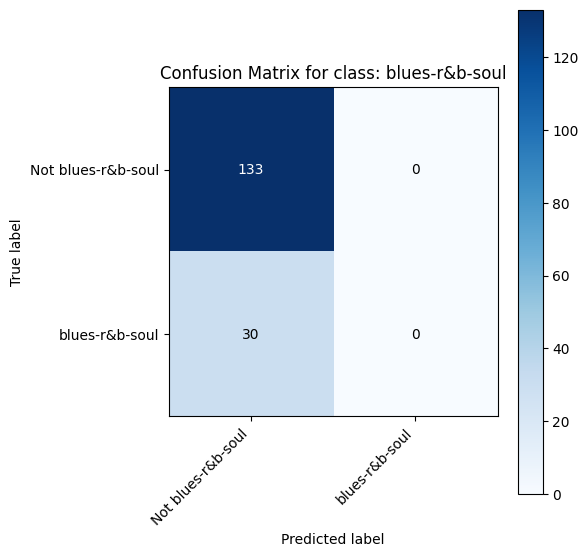

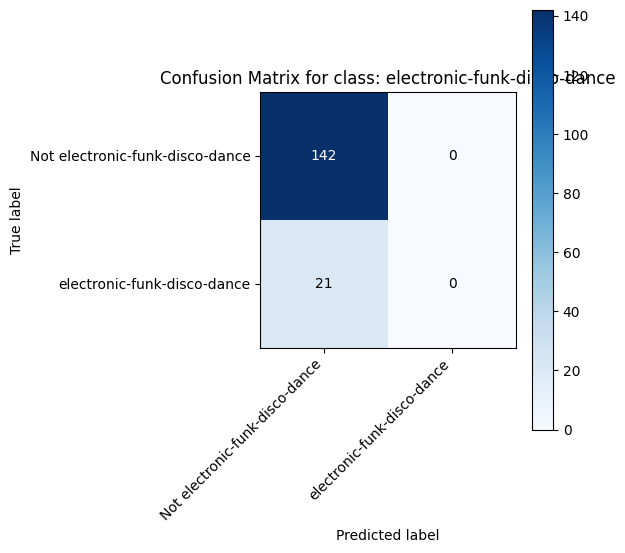

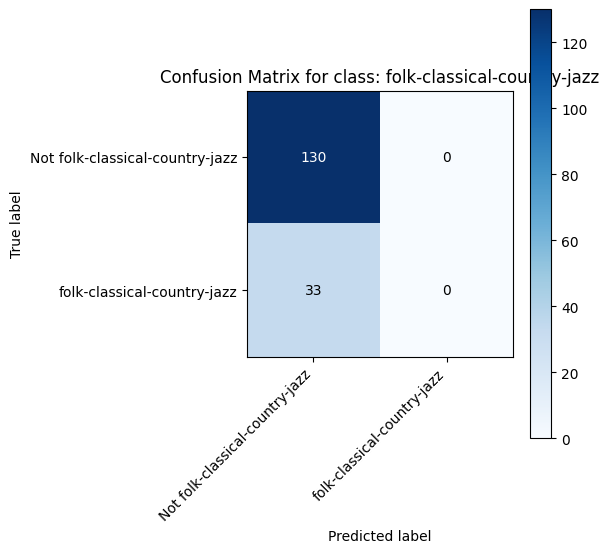

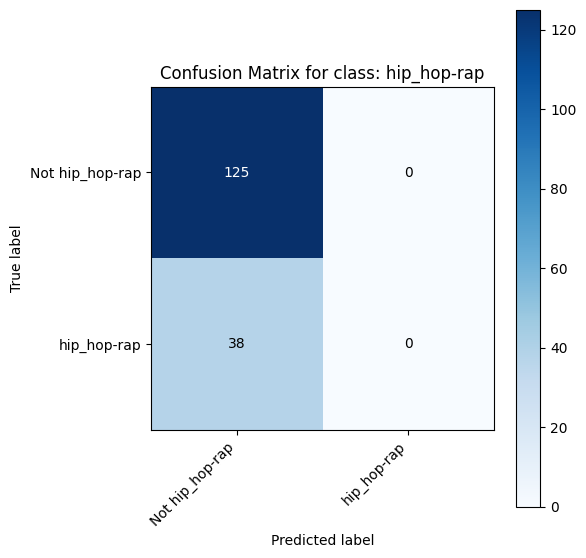

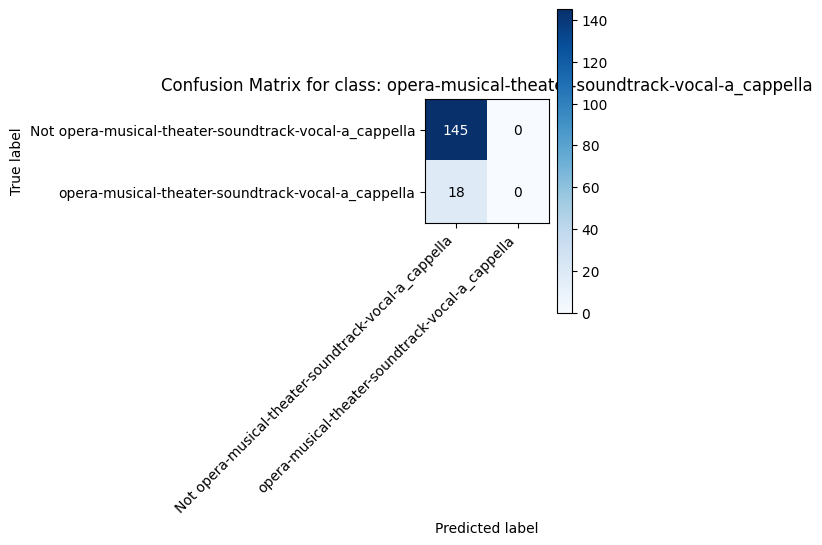

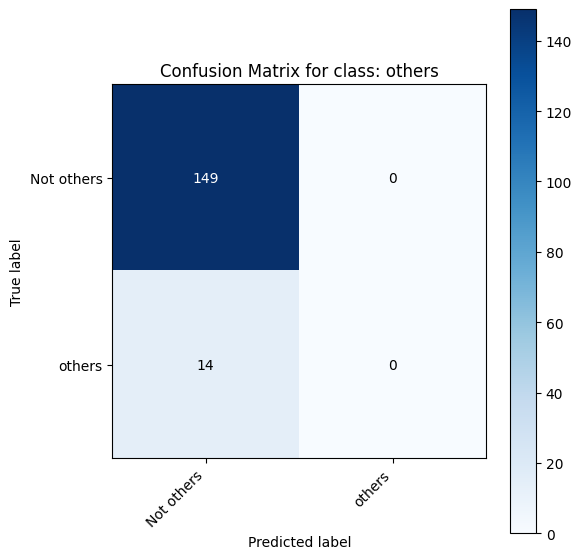

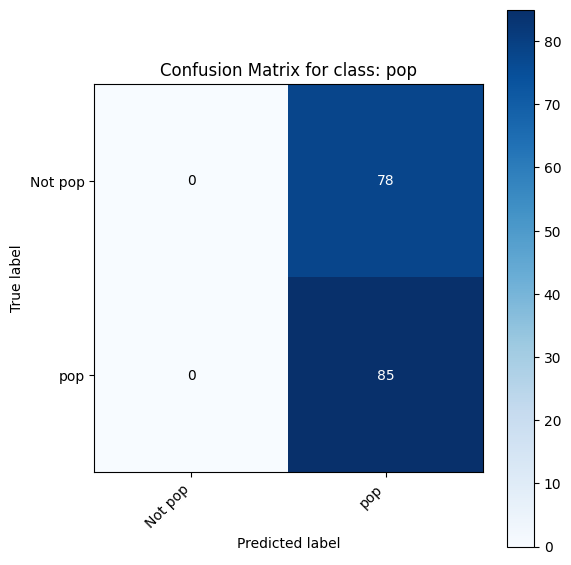

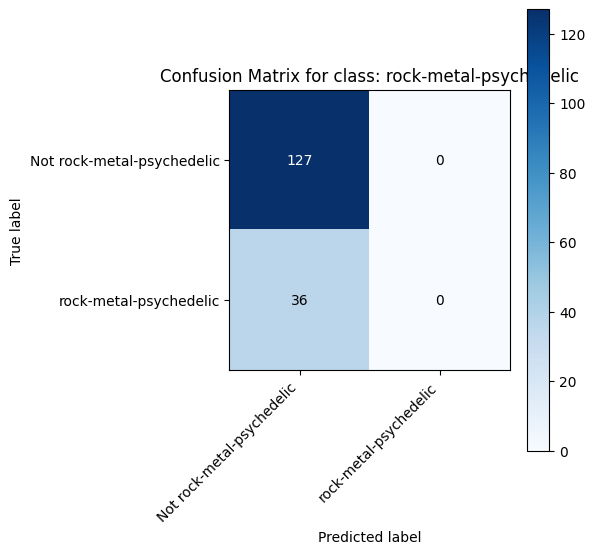

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Plot confusion matrix per class
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

EFFICIENTNET-B3

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [ ]:
def build_efficientnetb3(input_shape=(250, 100, 3), n_labels=n_labels):
    base_model = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    base_model.trainable = False  # Freeze base layers initially

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(n_labels, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
# Build and compile model
efficientnetb3_model = build_efficientnetb3()
efficientnetb3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

efficientnetb3_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 250, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │        12,296 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,795,831 (41.18 MB)

 Trainable params: 12,296 (48.03 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
# Callbacks for training
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

In [ ]:
# Initial training with base frozen
history = efficientnetb3_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - auc_4: 0.4999 - binary_accuracy: 0.6644 - loss: 0.6196 - val_auc_4: 0.4966 - val_binary_accuracy: 0.7799 - val_loss: 0.5342 - learning_rate: 1.0000e-04
Epoch 2/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - auc_4: 0.5170 - binary_accuracy: 0.7784 - loss: 0.5316 - val_auc_4: 0.4986 - val_binary_accuracy: 0.7799 - val_loss: 0.4989 - learning_rate: 1.0000e-04
Epoch 3/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - auc_4: 0.5197 - binary_accuracy: 0.7854 - loss: 0.5050 - val_auc_4: 0.4981 - val_binary_accuracy: 0.7889 - val_loss: 0.4894 - learning_rate: 1.0000e-04
Epoch 4/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - auc_4: 0.4901 - binary_accuracy: 0.7817 - loss: 0.4914 - val_auc_4: 0.4941 - val_binary_accuracy: 0.7889 - val_loss: 0.4872 - learning_rate: 1.0000e-04
Epoch 5/65
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - auc_4: 0.5035 - binary_accuracy: 0.7909 - loss: 0.4891 - val_auc_4: 0.4895 - val_binary_accuracy: 0.7889 - val_loss: 0.4865 - 

In [ ]:
# Unfreeze base model for fine-tuning
efficientnetb3_model.layers[1].trainable = True

In [ ]:
# Recompile with lower learning rate for fine-tuning
efficientnetb3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(curve='ROC', multi_label=True), 'binary_accuracy']
)

In [ ]:
# Fine-tune for remaining epochs
history_finetune = efficientnetb3_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS // 2,
    callbacks=callbacks
)

Epoch 1/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 214s 4s/step - auc_5: 0.4806 - binary_accuracy: 0.2923 - loss: 0.9989 - val_auc_5: 0.5099 - val_binary_accuracy: 0.7889 - val_loss: 0.4902 - learning_rate: 1.0000e-05
Epoch 2/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - auc_5: 0.4986 - binary_accuracy: 0.3204 - loss: 0.9344 - val_auc_5: 0.5232 - val_binary_accuracy: 0.7799 - val_loss: 0.4998 - learning_rate: 1.0000e-05
Epoch 3/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - auc_5: 0.5096 - binary_accuracy: 0.3539 - loss: 0.8707 - val_auc_5: 0.4800 - val_binary_accuracy: 0.7799 - val_loss: 0.5271 - learning_rate: 1.0000e-05
Epoch 4/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - auc_5: 0.5119 - binary_accuracy: 0.4209 - loss: 0.8041 - val_auc_5: 0.4267 - val_binary_accuracy: 0.7799 - val_loss: 0.5341 - learning_rate: 1.0000e-05
Epoch 5/32
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - auc_5: 0.5251 - binary_accuracy: 0.4982 - loss: 0.7371 - val_auc_5: 0.5292 - val_binary_accuracy: 0.7799 - val_loss: 0.5071

In [ ]:
# Save model and download if in Colab
efficientnetb3_model.save('efficientnetb3_model_final.h5')
try:
    from google.colab import files
    files.download('efficientnetb3_model_final.h5')
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Evaluate on test set
print("\nEvaluating on test set:")
test_results = efficientnetb3_model.evaluate(test_ds)
print(test_results)


Evaluating on test set:
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - auc_5: 0.5094 - binary_accuracy: 0.7871 - loss: 0.4782
[0.4771895706653595, 0.5269522070884705, 0.7891104221343994]


In [ ]:
# Confusion matrix plot utility
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha='right')
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
# Generate predictions and true labels
pred_probs = []
true_labels = []

for x_batch, y_batch in test_ds:
    preds = efficientnetb3_model.predict(x_batch)
    pred_probs.append(preds)
    true_labels.append(y_batch.numpy())

pred_probs = np.vstack(pred_probs)
true_labels = np.vstack(true_labels)
pred_labels = (pred_probs > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


In [ ]:
# Overall binary accuracy
binary_accuracy = accuracy_score(true_labels.flatten(), pred_labels.flatten())
print(f"Overall binary accuracy: {binary_accuracy:.4f}")

Overall binary accuracy: 0.7891


Classification Report (per label):
                                                   precision    recall  f1-score   support

                                   blues-r&b-soul       0.00      0.00      0.00        30
                      electronic-funk-disco-dance       0.00      0.00      0.00        21
                      folk-classical-country-jazz       0.00      0.00      0.00        33
                                      hip_hop-rap       0.00      0.00      0.00        38
opera-musical-theater-soundtrack-vocal-a_cappella       0.00      0.00      0.00        18
                                           others       0.00      0.00      0.00        14
                                              pop       0.00      0.00      0.00        85
                           rock-metal-psychedelic       0.00      0.00      0.00        36

                                        micro avg       0.00      0.00      0.00       275
                                        macro avg    

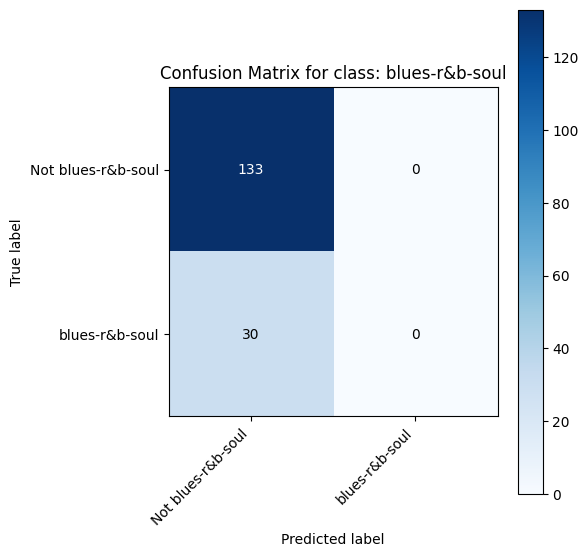

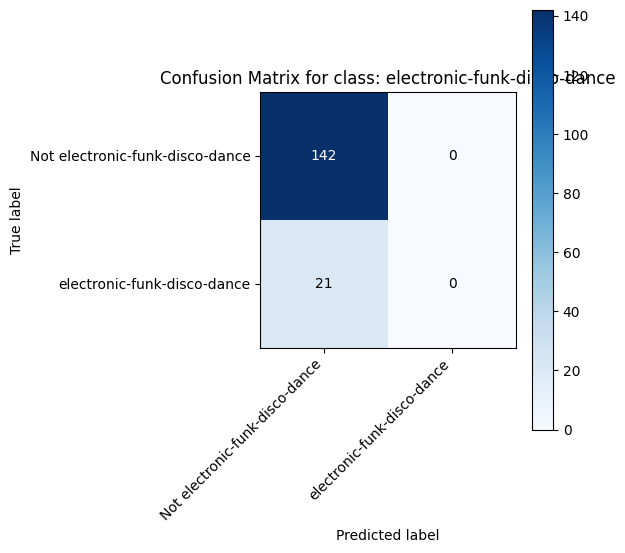

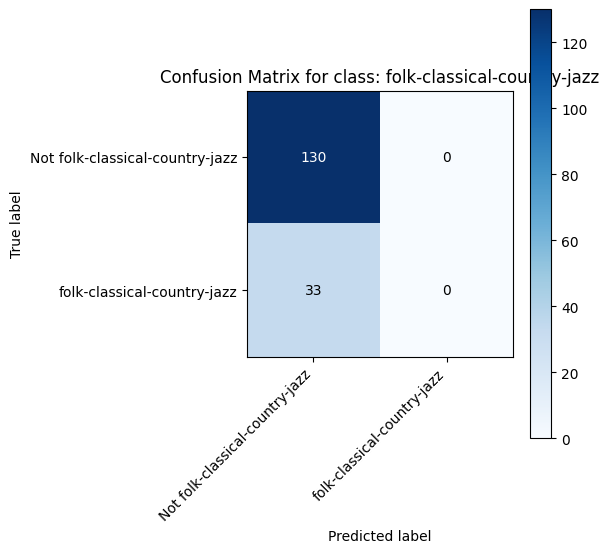

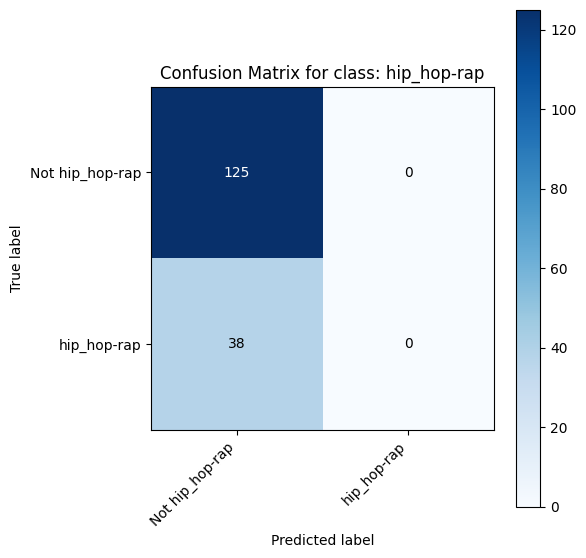

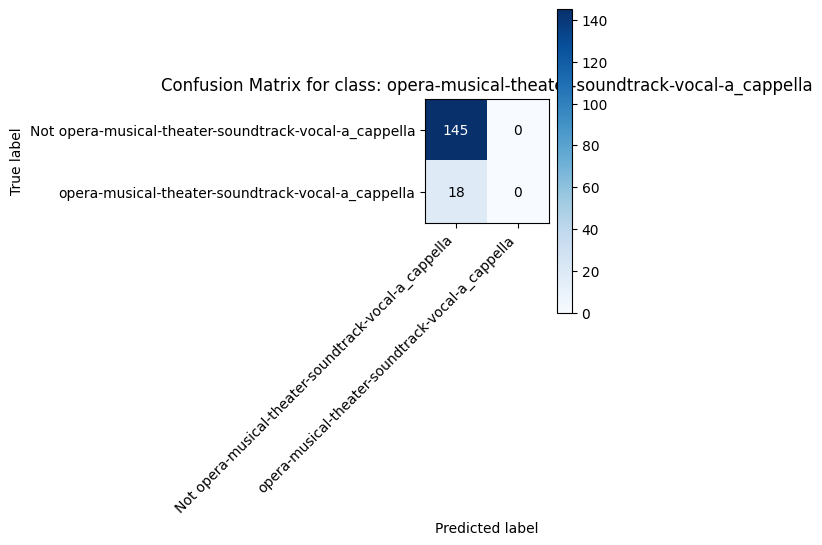

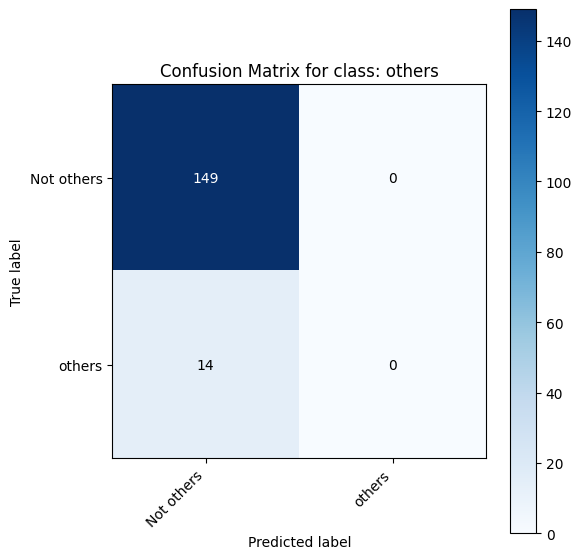

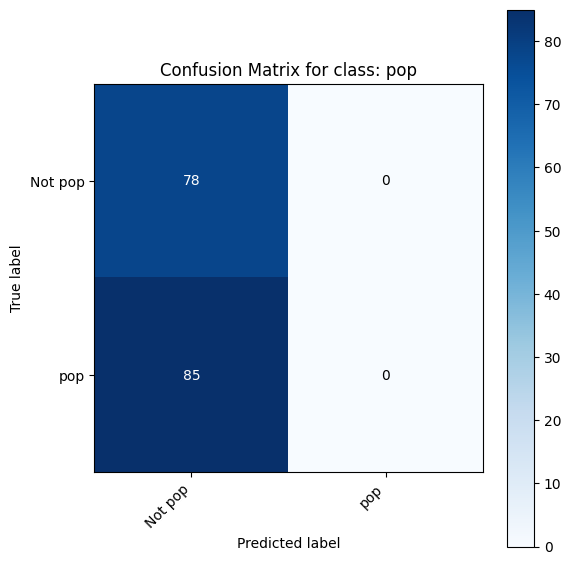

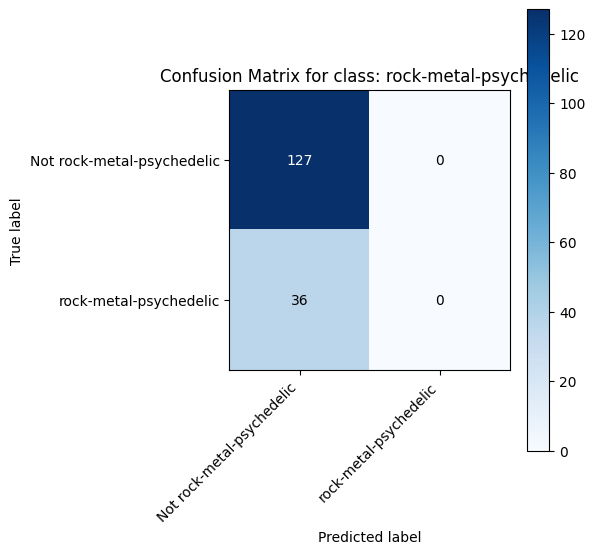

In [ ]:
# Classification report
print("Classification Report (per label):")
print(classification_report(true_labels, pred_labels, target_names=mlb.classes_, zero_division=0))

# Plot confusion matrix per class
for idx, class_name in enumerate(mlb.classes_):
    cm = confusion_matrix(true_labels[:, idx], pred_labels[:, idx])
    plot_confusion_matrix(cm, classes=[f'Not {class_name}', class_name],
                          title=f'Confusion Matrix for class: {class_name}', normalize=False)

## Comprehensive Comparative Evaluation of CNN Architectures

This table summarizes the final test performance of all implemented architectures on the **Multi-Label Spectrogram Music Tagging** task, ranked by the most robust multi-label metric ($\text{Macro F1}$).

| Rank (by Macro F1) | Model Architecture | Max Binary Accuracy | Max AUC Score | **Test Macro F1** | Key Finding |
| :---: | :--- | :---: | :---: | :---: | :--- |
| **1** | **LeNet-5 (Custom)** | $0.8420$ (Test) | $\mathbf{0.7968}$ | **0.48** | **Most Robust & Balanced.** Achieved the highest $\text{Macro F1}$, indicating the best generalization across all 8 tags. |
| **2** | **VGG11 (Custom)** | $\mathbf{0.8497}$ (Test) | $0.7950$ | $0.41$ | **Highest Accuracy.** Peak overall $\text{Binary Accuracy}$, but $\text{Macro F1}$ gap shows performance bias toward majority tags. |
| 3 | **AlexNet (Custom)** | $0.7891$ (Test) | $0.5427$ | $0.41$ | Simple network achieved good $\text{Macro F1}$, but $\text{Binary Accuracy}$ is average. |
| 4 | **VGG13 (Custom)** | $0.8397$ (Test) | $0.7977$ | $0.29$ | High accuracy masked a low $\text{Macro F1}$, confirming it struggles severely with niche tags. |
| 5 | **ResNeXt (Custom)** | $0.8359$ (Test) | $0.7759$ | $0.22$ | High misleading accuracy. Custom network shows high True Negative performance but low Recall on rare tags. |
| 6 | **Hyperparameter Tuned CNN** | $\mathbf{0.8048}$ (Val) | $0.7961$ (Val) | N/A* | **Best Potential.** Validation score shows massive $\mathbf{\approx 28\%}$ improvement over the Vanilla Custom CNN. |
| 7 | **InceptionV3** (Fine-tuned) | $0.8113$ (Test) | $0.6658$ | $0.14$ | The best $\text{Binary Accuracy}$ among transfer learning models, but $\text{Macro F1}$ is poor. |
| 8 | **DenseNet121** (Fine-tuned) | $0.7991$ (Test) | $0.6449$ | $0.14$ | Fine-tuning failed to stabilize multi-label predictions across all tags. |
| 9 | **ResNet50** (Fine-tuned) | $0.7945$ (Test) | $0.5041$ | $0.09$ | Transfer learning failed; $\text{AUC}$ barely above $0.50$ suggests features were not well-learned for the task. |
| 10 | **Vanilla Custom CNN** | $0.5245$ (Test) | $0.5031$ (Test) | $\approx 0.00$ | **Baseline Failure.** Initial, fixed hyperparameters were completely inadequate for distinguishing between tags. |
| 11 | **VGG16/VGG19/EffNetB3** | $\approx 0.7891$ (Test) | $\approx 0.53$ | $\mathbf{0.00}$ | **Catastrophic Failure.** These deep models defaulted to predicting the majority class only ($\text{True Negatives}$). |

*\*Note: $\text{Macro F1}$ for the Hyperparameter Tuned CNN is not available from the provided Keras Tuner validation output.*